# EDA cho Criteo Uplift Dataset

Notebook này dùng cho **data exploration** của Criteo Uplift Dataset theo hướng phù hợp với **uplift modeling / causal ML**.

Điểm quan trọng:
- Dataset có các feature ẩn danh dạng `f0`, `f1`, ... nên không thể diễn giải ý nghĩa business thật của từng feature.
- Cần phân tích theo vai trò cột: **features**, **treatment/exposure**, và **outcomes** (`visit`, `conversion`).
- Với uplift dataset, phần quan trọng nhất không chỉ là phân phối feature, mà là: `treatment vs control`, balance giữa hai nhóm, outcome rate theo nhóm, và uplift theo từng lát cắt feature.

Nguồn tham khảo:
- Criteo AI Lab: https://ailab.criteo.com/criteo-uplift-prediction-dataset/
- Hugging Face dataset: https://huggingface.co/datasets/criteo/criteo-uplift
- scikit-uplift docs: https://www.uplift-modeling.com/en/latest/api/datasets/fetch_criteo.html

## 0. Cài đặt và import thư viện

Cell này chuẩn bị các thư viện cần thiết. Notebook ưu tiên dùng `pandas`, `numpy`, `matplotlib`. Nếu có `scipy`, ta sẽ dùng thêm để tính KS statistic khi kiểm tra balance giữa treatment và control.

In [22]:
# Nếu thiếu thư viện, bạn có thể mở comment dòng dưới:
# !pip install pandas numpy matplotlib scipy pyarrow datasets

import os
import gc
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

try:
    from scipy.stats import ks_2samp
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("scipy available:", SCIPY_AVAILABLE)

scipy available: True


## 1. Load dữ liệu

Bạn có 2 cách dùng:

1. **Đọc trực tiếp từ Hugging Face** bằng URL CSV `.gz`.
2. **Đọc từ file local** nếu bạn đã tải dataset về máy.

Dataset khá lớn, vì vậy notebook để sẵn `NROWS`. Khi mới explore, nên đặt `NROWS = 500_000` hoặc `1_000_000`. Khi cần thống kê cuối cùng, có thể đặt `NROWS = None` để đọc toàn bộ nếu máy đủ RAM.

In [23]:
# ======================
# CẤU HÌNH LOAD DỮ LIỆU
# ======================

DATA_SOURCE = "hf_csv"   # "hf_csv" hoặc "local_csv"

# URL file CSV gzip trên Hugging Face.
# Nếu đường dẫn thay đổi, hãy tải thủ công từ trang dataset rồi dùng DATA_SOURCE = "local_csv".
HF_CSV_URL = "https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/criteo-research-uplift-v2.1.csv.gz"

# Nếu bạn dùng file local, sửa đường dẫn tại đây.
LOCAL_CSV_PATH = "criteo-research-uplift-v2.1.csv.gz"

# Đặt None để đọc toàn bộ. Đặt số nguyên để đọc nhanh một phần dữ liệu.
# Gợi ý: bắt đầu với 500_000 hoặc 1_000_000 cho EDA nhanh.
NROWS = None


def load_criteo_data(data_source="hf_csv", nrows=500_000, local_path=None):
    """Load Criteo Uplift Dataset từ Hugging Face hoặc file local."""
    if data_source == "hf_csv":
        path = HF_CSV_URL
    elif data_source == "local_csv":
        if local_path is None:
            raise ValueError("Bạn cần truyền local_path khi DATA_SOURCE='local_csv'.")
        path = local_path
    else:
        raise ValueError("DATA_SOURCE phải là 'hf_csv' hoặc 'local_csv'.")

    print(f"Loading from: {path}")
    print(f"nrows: {nrows}")

    df = pd.read_csv(path, compression="infer", nrows=nrows)
    return df


df = load_criteo_data(DATA_SOURCE, nrows=NROWS, local_path=LOCAL_CSV_PATH)

print("Loaded shape:", df.shape)
display(df.head())

Loading from: https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/criteo-research-uplift-v2.1.csv.gz
nrows: None
Loaded shape: (13979592, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


## 2. Tối ưu kiểu dữ liệu và kiểm tra tổng quan

Mục tiêu:
- Xem dataset có bao nhiêu dòng, bao nhiêu cột.
- Xem tên cột, kiểu dữ liệu, memory usage.
- Downcast các cột số để giảm RAM, nhất là khi đọc toàn bộ dataset.

In [24]:
def memory_usage_mb(dataframe):
    return dataframe.memory_usage(deep=True).sum() / 1024**2

print("Shape:", df.shape)
print(f"Memory before optimization: {memory_usage_mb(df):,.2f} MB")

display(pd.DataFrame({
    "column": df.columns,
    "dtype": [df[c].dtype for c in df.columns],
    "n_unique": [df[c].nunique(dropna=False) for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns]
}))


def optimize_numeric_dtypes(dataframe):
    """Downcast int/float columns để tiết kiệm RAM."""
    out = dataframe.copy()
    for col in out.columns:
        if pd.api.types.is_integer_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="float")
    return out


df = optimize_numeric_dtypes(df)
print(f"Memory after optimization: {memory_usage_mb(df):,.2f} MB")

display(df.dtypes.to_frame("dtype"))

Shape: (13979592, 16)
Memory before optimization: 1,706.49 MB


,column,dtype,n_unique,missing
0,f0,float64,2181959,0
1,f1,float64,60,0
2,f2,float64,2051900,0
3,f3,float64,552,0
4,f4,float64,260,0
5,f5,float64,132,0
6,f6,float64,1645,0
7,f7,float64,622143,0
8,f8,float64,3743,0
9,f9,float64,1594,0


Memory after optimization: 693.26 MB


,dtype
f0,float32
f1,float32
f2,float32
f3,float32
f4,float32
f5,float32
f6,float32
f7,float32
f8,float32
f9,float32


## 3. Xác định vai trò của từng cột

Với Criteo Uplift Dataset, nên tách cột theo vai trò:

- **Feature columns**: thường là `f0`, `f1`, ..., `f11`. Đây là feature đã ẩn danh.
- **Treatment columns**: `treatment`, có thể có thêm `exposure`.
- **Outcome columns**: `visit`, `conversion`.

Lưu ý: `treatment` và `exposure` không nên xem là giống nhau. `treatment` thường là chỉ báo nhóm treatment/control, còn `exposure` liên quan tới việc user thực sự được exposed với ad.

In [25]:
def sort_feature_cols(cols):
    """Sort f0, f1, ..., f11 theo thứ tự số."""
    def key_fn(c):
        try:
            return int(c[1:])
        except Exception:
            return 10**9
    return sorted(cols, key=key_fn)

feature_cols = sort_feature_cols([c for c in df.columns if c.startswith("f") and c[1:].isdigit()])
treatment_cols = [c for c in ["treatment", "exposure"] if c in df.columns]
outcome_cols = [c for c in ["visit", "conversion"] if c in df.columns]
other_cols = [c for c in df.columns if c not in feature_cols + treatment_cols + outcome_cols]

column_roles = pd.DataFrame({
    "role": ["feature"] * len(feature_cols) + ["treatment_related"] * len(treatment_cols) + ["outcome"] * len(outcome_cols) + ["other"] * len(other_cols),
    "column": feature_cols + treatment_cols + outcome_cols + other_cols
})

display(column_roles)

print("Feature columns:", feature_cols)
print("Treatment-related columns:", treatment_cols)
print("Outcome columns:", outcome_cols)
print("Other columns:", other_cols)

,role,column
0,feature,f0
1,feature,f1
2,feature,f2
3,feature,f3
4,feature,f4
5,feature,f5
6,feature,f6
7,feature,f7
8,feature,f8
9,feature,f9


Feature columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
Treatment-related columns: ['treatment', 'exposure']
Outcome columns: ['visit', 'conversion']
Other columns: []


## 4. Data quality: missing, infinite, duplicate, constant columns

Mục tiêu:
- Kiểm tra missing values theo từng cột.
- Kiểm tra giá trị vô hạn `inf`, `-inf`.
- Kiểm tra duplicate rows.
- Tìm cột constant hoặc near-constant, vì các cột này thường không hữu ích cho modeling.

Với dataset rất lớn, duplicate check toàn bộ có thể tốn thời gian. Cell này có biến cấu hình để bạn chọn kiểm tra trên full data hoặc sample.

In [26]:
# ======================
# MISSING VALUES
# ======================

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean()
}).sort_values("missing_rate", ascending=False)

display(missing_summary)

# ======================
# INFINITE VALUES
# ======================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

inf_summary = pd.DataFrame(index=numeric_cols)
inf_summary["positive_inf"] = [np.isposinf(df[c]).sum() for c in numeric_cols]
inf_summary["negative_inf"] = [np.isneginf(df[c]).sum() for c in numeric_cols]
inf_summary["total_inf"] = inf_summary["positive_inf"] + inf_summary["negative_inf"]
inf_summary = inf_summary.sort_values("total_inf", ascending=False)

display(inf_summary)

# ======================
# DUPLICATES
# ======================

CHECK_DUPLICATES_FULL = False
DUP_SAMPLE_N = min(len(df), 200_000)

if CHECK_DUPLICATES_FULL:
    dup_count = df.duplicated().sum()
    print(f"Duplicate rows on full data: {dup_count:,} / {len(df):,}")
else:
    dup_df = df.sample(DUP_SAMPLE_N, random_state=RANDOM_STATE) if len(df) > DUP_SAMPLE_N else df
    dup_count = dup_df.duplicated().sum()
    print(f"Duplicate rows on sample: {dup_count:,} / {len(dup_df):,}")

# ======================
# CONSTANT / NEAR-CONSTANT COLUMNS
# ======================

nunique_summary = pd.DataFrame({
    "n_unique": df.nunique(dropna=False),
    "unique_rate": df.nunique(dropna=False) / len(df)
}).sort_values("n_unique")

display(nunique_summary)

constant_cols = nunique_summary[nunique_summary["n_unique"] <= 1].index.tolist()
near_constant_cols = nunique_summary[nunique_summary["unique_rate"] <= 0.001].index.tolist()

print("Constant columns:", constant_cols)
print("Near-constant columns unique_rate <= 0.1%:", near_constant_cols)

,missing_count,missing_rate
f0,0,0.000000
f1,0,0.000000
f2,0,0.000000
f3,0,0.000000
f4,0,0.000000
f5,0,0.000000
f6,0,0.000000
f7,0,0.000000
f8,0,0.000000
f9,0,0.000000


,positive_inf,negative_inf,total_inf
f0,0,0,0
f1,0,0,0
f2,0,0,0
f3,0,0,0
f4,0,0,0
f5,0,0,0
f6,0,0,0
f7,0,0,0
f8,0,0,0
f9,0,0,0


Duplicate rows on sample: 451 / 200,000


,n_unique,unique_rate
treatment,2,0.000000
conversion,2,0.000000
visit,2,0.000000
exposure,2,0.000000
f1,60,0.000004
f5,132,0.000009
f11,136,0.000010
f4,260,0.000019
f3,552,0.000039
f9,1594,0.000114


Constant columns: []
Near-constant columns unique_rate <= 0.1%: ['treatment', 'conversion', 'visit', 'exposure', 'f1', 'f5', 'f11', 'f4', 'f3', 'f9', 'f6', 'f8']


## 5. Dataset overview: số dòng, số cột, sample rows, summary statistics

Mục này trả lời các câu hỏi cơ bản:

- Data có bao nhiêu dòng và cột?
- Có những feature nào?
- Kiểu dữ liệu ra sao?
- Các thống kê mô tả cơ bản của feature như min, max, mean, std, quantile là gì?

In [27]:
print("Number of rows:", f"{len(df):,}")
print("Number of columns:", f"{df.shape[1]:,}")
print("Number of feature columns:", len(feature_cols))
print("Feature columns:", feature_cols)

print("\nSample rows:")
display(df.head(10))

# Summary statistics cho feature columns
if feature_cols:
    feature_summary = df[feature_cols].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ).T

    feature_summary["missing_rate"] = df[feature_cols].isna().mean()
    feature_summary["skew"] = df[feature_cols].skew(numeric_only=True)
    feature_summary["kurtosis"] = df[feature_cols].kurtosis(numeric_only=True)

    display(feature_summary)
else:
    print("Không tìm thấy feature columns dạng f0, f1, ...")

Number of rows: 13,979,592
Number of columns: 16
Number of feature columns: 12
Feature columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

Sample rows:


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616364,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616364,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616364,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616364,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616364,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
5,12.616364,10.059654,8.904507,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
6,12.616364,10.059654,8.783340,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
7,12.616364,10.059654,8.964528,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
8,12.616364,10.059654,9.037808,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
9,12.616364,10.059654,9.015127,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_rate,skew,kurtosis
f0,"13,979,592.000000",19.620296,5.377464,12.616364,12.616364,12.616364,12.616364,21.923413,24.436459,26.311867,26.672877,26.745255,0.000000,-0.245829,-1.626658
f1,"13,979,592.000000",10.069978,0.104756,10.059654,10.059654,10.059654,10.059654,10.059654,10.059654,10.059654,10.679513,16.344187,0.000000,13.997746,267.553497
f2,"13,979,592.000000",8.446583,0.299316,8.214383,8.214383,8.214383,8.214383,8.214383,8.723335,9.004230,9.042916,9.051962,0.000000,0.806385,-1.008583
f3,"13,979,592.000000",4.178923,1.336645,-8.398387,-1.733228,0.973841,4.679882,4.679882,4.679882,4.679882,4.679882,4.679882,0.000000,-3.186468,10.514234
f4,"13,979,592.000000",10.338838,0.343308,10.280525,10.280525,10.280525,10.280525,10.280525,10.280525,10.280525,11.973288,21.123508,0.000000,8.882762,104.134811
f5,"13,979,592.000000",4.028512,0.431097,-9.011891,2.230907,3.013064,4.115453,4.115453,4.115453,4.115453,4.115453,4.115453,0.000000,-7.085843,68.820396
f6,"13,979,592.000000",-4.155355,4.577914,-31.429783,-17.777273,-13.353455,-6.699321,-2.411115,0.294443,0.294443,0.294443,0.294443,0.000000,-1.135889,0.773958
f7,"13,979,592.000000",5.101766,1.205248,4.833815,4.833815,4.833815,4.833815,4.833815,4.833815,6.045297,11.482084,11.998401,0.000000,4.524972,19.223021
f8,"13,979,592.000000",3.933581,0.056660,3.635107,3.751603,3.806309,3.910792,3.971858,3.971858,3.971858,3.971858,3.971858,0.000000,-1.605565,1.853786
f9,"13,979,592.000000",16.027639,7.018975,13.190056,13.190056,13.190056,13.190056,13.190056,13.190056,33.712555,44.893639,75.295021,0.000000,2.822741,7.726638


## 6. Ý nghĩa của feature

Vì các feature `f0`, `f1`, ... đã được ẩn danh / biến đổi để bảo vệ quyền riêng tư, notebook không nên gán ý nghĩa business tùy tiện cho từng feature.

Thay vào đó, ta mô tả feature theo các thông tin có thể quan sát:

- Kiểu dữ liệu.
- Miền giá trị.
- Missing rate.
- Phân phối.
- Quan hệ với treatment/control.
- Quan hệ với outcome và uplift.

In [28]:
feature_dictionary = []

for col in feature_cols:
    s = df[col]
    feature_dictionary.append({
        "column": col,
        "business_meaning": "Ẩn danh / không được công bố",
        "dtype": str(s.dtype),
        "missing_rate": s.isna().mean(),
        "n_unique": s.nunique(dropna=False),
        "min": s.min(skipna=True),
        "max": s.max(skipna=True),
        "mean": s.mean(skipna=True),
        "std": s.std(skipna=True),
    })

feature_dictionary = pd.DataFrame(feature_dictionary)
display(feature_dictionary)

,column,business_meaning,dtype,missing_rate,n_unique,min,max,mean,std
0,f0,Ẩn danh / không được công bố,float32,0.000000,2181959,12.616364,26.745255,19.620296,5.377464
1,f1,Ẩn danh / không được công bố,float32,0.000000,60,10.059654,16.344187,10.069978,0.104756
2,f2,Ẩn danh / không được công bố,float32,0.000000,808663,8.214383,9.051962,8.446583,0.299316
3,f3,Ẩn danh / không được công bố,float32,0.000000,552,-8.398387,4.679882,4.178923,1.336645
4,f4,Ẩn danh / không được công bố,float32,0.000000,260,10.280525,21.123508,10.338838,0.343308
5,f5,Ẩn danh / không được công bố,float32,0.000000,132,-9.011891,4.115453,4.028512,0.431097
6,f6,Ẩn danh / không được công bố,float32,0.000000,1645,-31.429783,0.294443,-4.155355,4.577914
7,f7,Ẩn danh / không được công bố,float32,0.000000,622143,4.833815,11.998401,5.101766,1.205248
8,f8,Ẩn danh / không được công bố,float32,0.000000,3743,3.635107,3.971858,3.933581,0.056660
9,f9,Ẩn danh / không được công bố,float32,0.000000,1594,13.190056,75.295021,16.027639,7.018975


## 7. Treatment, exposure và outcome overview

Đây là phần rất quan trọng với uplift dataset.

Cần xem:
- Số lượng treatment và control.
- Tỷ lệ treatment/control.
- Số lượng exposed/non-exposed nếu có cột `exposure`.
- Tỷ lệ `visit` và `conversion` toàn dataset.
- Tỷ lệ `visit` và `conversion` theo từng nhóm treatment/control.

In [29]:
def binary_column_summary(dataframe, cols):
    rows = []
    for col in cols:
        vc = dataframe[col].value_counts(dropna=False).sort_index()
        for value, count in vc.items():
            rows.append({
                "column": col,
                "value": value,
                "count": count,
                "rate": count / len(dataframe)
            })
    return pd.DataFrame(rows)

binary_cols_to_check = treatment_cols + outcome_cols
binary_summary = binary_column_summary(df, binary_cols_to_check)
display(binary_summary)

# Outcome rate toàn dataset
if outcome_cols:
    outcome_overall = pd.DataFrame({
        "positive_count": df[outcome_cols].sum(),
        "positive_rate": df[outcome_cols].mean()
    })
    display(outcome_overall)

# Outcome rate theo treatment
if "treatment" in df.columns and outcome_cols:
    outcome_by_treatment = df.groupby("treatment")[outcome_cols].agg(["count", "sum", "mean"])
    display(outcome_by_treatment)

# Crosstab treatment vs exposure nếu có cả 2 cột
if "treatment" in df.columns and "exposure" in df.columns:
    print("Crosstab count: treatment x exposure")
    display(pd.crosstab(df["treatment"], df["exposure"], margins=True))

    print("Crosstab row-normalized: treatment x exposure")
    display(pd.crosstab(df["treatment"], df["exposure"], normalize="index"))

,column,value,count,rate
0,treatment,0,2096937,0.150000
1,treatment,1,11882655,0.850000
2,exposure,0,13551380,0.969369
3,exposure,1,428212,0.030631
4,visit,0,13322663,0.953008
5,visit,1,656929,0.046992
6,conversion,0,13938818,0.997083
7,conversion,1,40774,0.002917


,positive_count,positive_rate
visit,656929,0.046992
conversion,40774,0.002917


visit                  conversion                
              count     sum     mean      count    sum     mean
treatment                                                      
0           2096937   80105 0.038201    2096937   4063 0.001938
1          11882655  576824 0.048543   11882655  36711 0.003089

Crosstab count: treatment x exposure


exposure,0,1,All
treatment,,,
0,2096937,0,2096937
1,11454443,428212,11882655
All,13551380,428212,13979592


Crosstab row-normalized: treatment x exposure


exposure,0,1
treatment,,
0,1.000000,0.000000
1,0.963963,0.036037


## 8. Baseline uplift: treatment rate - control rate

Uplift cơ bản được tính bằng chênh lệch outcome rate giữa treatment và control:

\[
\text{uplift} = P(Y=1 \mid T=1) - P(Y=1 \mid T=0)
\]

Ta tính riêng cho `visit` và `conversion` nếu có cả hai cột. Đây là baseline thô, chưa điều chỉnh theo feature.

In [30]:
def compute_baseline_uplift(dataframe, treatment_col="treatment", outcome_cols=None):
    if outcome_cols is None:
        outcome_cols = ["visit", "conversion"]
    outcome_cols = [c for c in outcome_cols if c in dataframe.columns]

    rows = []
    for outcome in outcome_cols:
        tmp = dataframe[[treatment_col, outcome]].dropna()
        if tmp[treatment_col].nunique() < 2:
            continue

        rate_t = tmp.loc[tmp[treatment_col] == 1, outcome].mean()
        rate_c = tmp.loc[tmp[treatment_col] == 0, outcome].mean()
        n_t = (tmp[treatment_col] == 1).sum()
        n_c = (tmp[treatment_col] == 0).sum()
        pos_t = tmp.loc[tmp[treatment_col] == 1, outcome].sum()
        pos_c = tmp.loc[tmp[treatment_col] == 0, outcome].sum()

        rows.append({
            "outcome": outcome,
            "n_treatment": n_t,
            "n_control": n_c,
            "positive_treatment": pos_t,
            "positive_control": pos_c,
            "rate_treatment": rate_t,
            "rate_control": rate_c,
            "absolute_uplift": rate_t - rate_c,
            "relative_lift": (rate_t / rate_c - 1) if rate_c > 0 else np.nan,
        })

    return pd.DataFrame(rows)

if "treatment" in df.columns:
    baseline_uplift = compute_baseline_uplift(df, "treatment", outcome_cols)
    display(baseline_uplift)
else:
    print("Không có cột treatment.")

,outcome,n_treatment,n_control,positive_treatment,positive_control,rate_treatment,rate_control,absolute_uplift,relative_lift
0,visit,11882655,2096937,576824,80105,0.048543,0.038201,0.010342,0.270737
1,conversion,11882655,2096937,36711,4063,0.003089,0.001938,0.001152,0.594488


## 9. Phân phối của từng feature: histogram và boxplot

Mục này gộp hai ý “phân bố” và “phân phối” thành một section: **univariate distribution**.

Với dataset lớn, ta dùng sample để vẽ biểu đồ. Thống kê aggregate có thể tính trên toàn bộ `df` đã load.

Plot sample shape: (200000, 16)


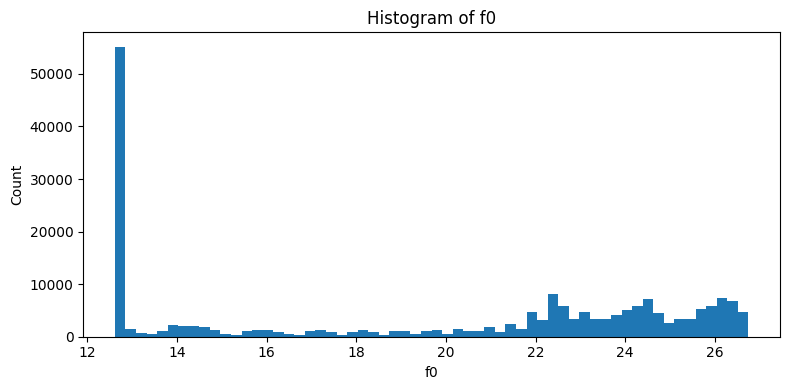

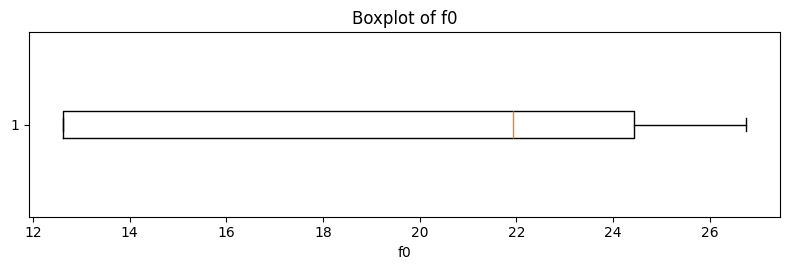

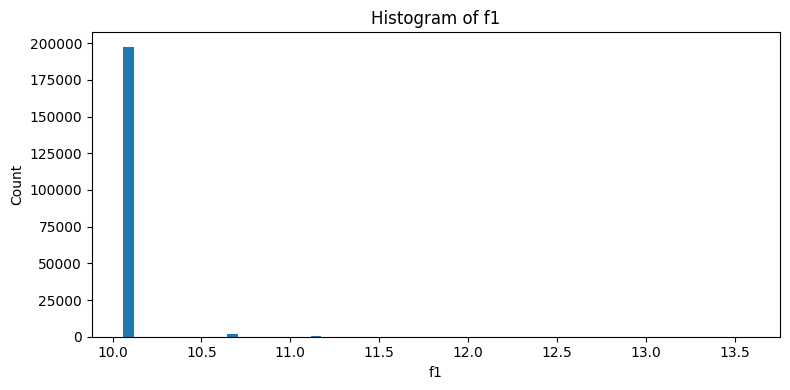

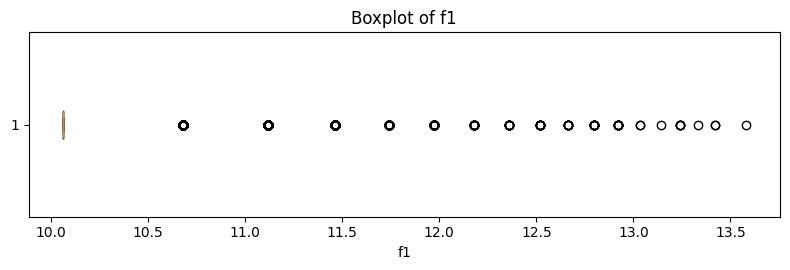

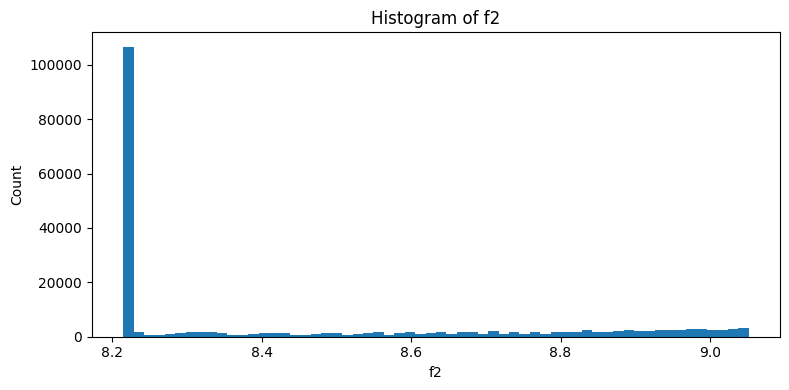

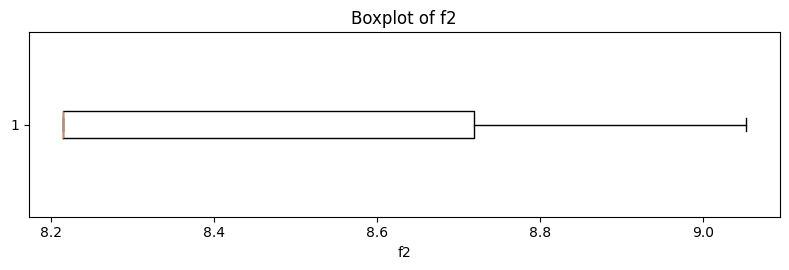

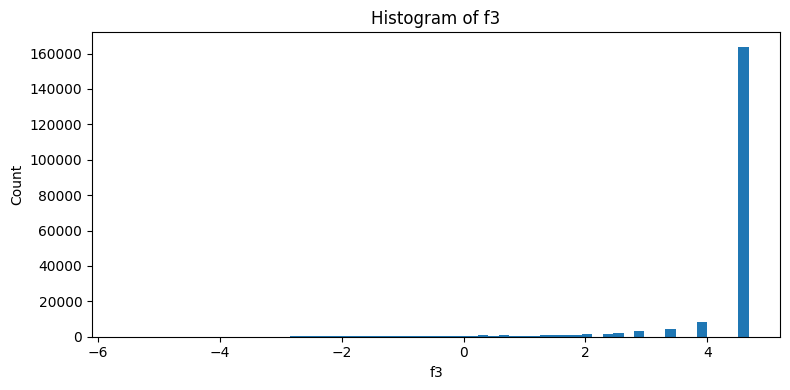

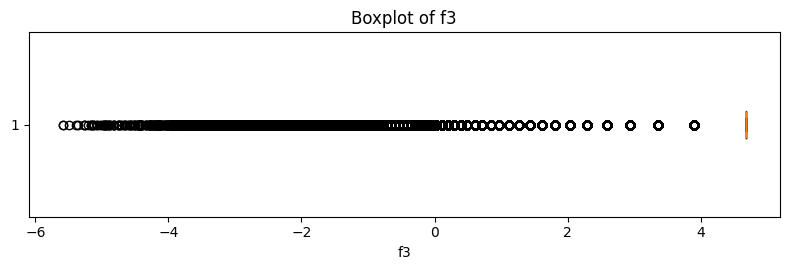

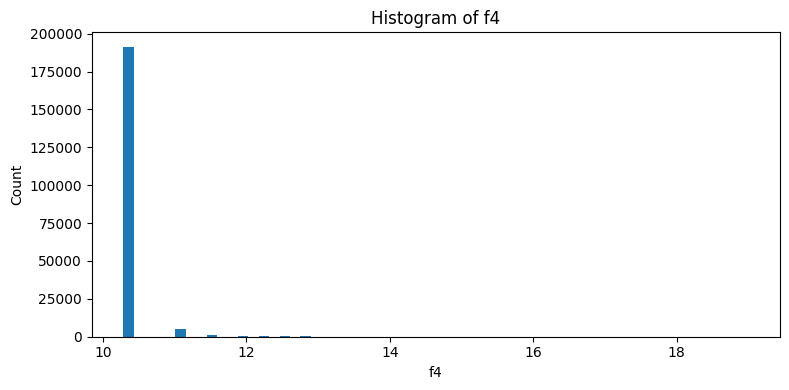

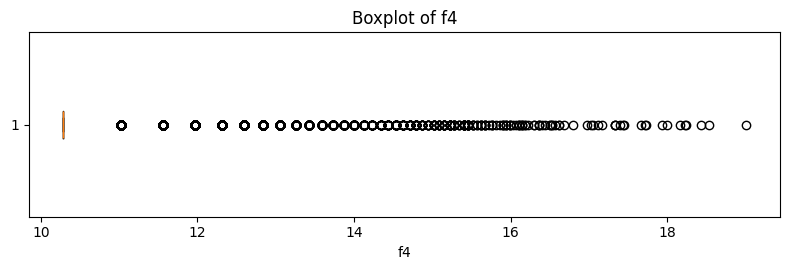

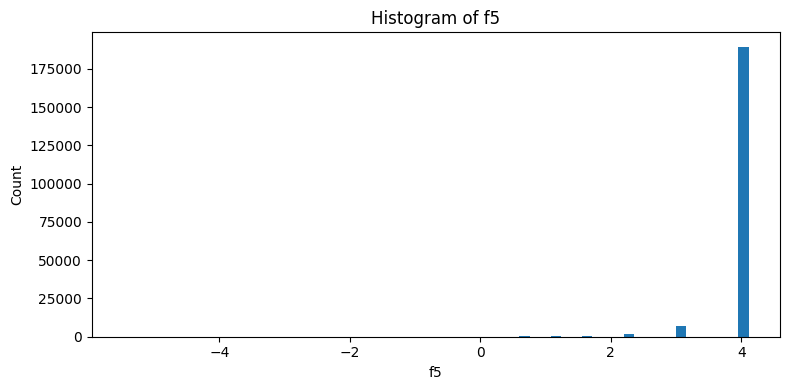

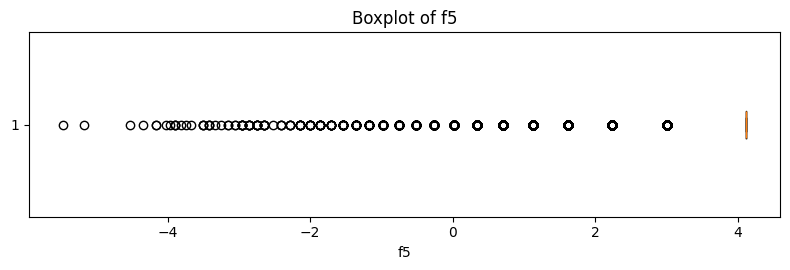

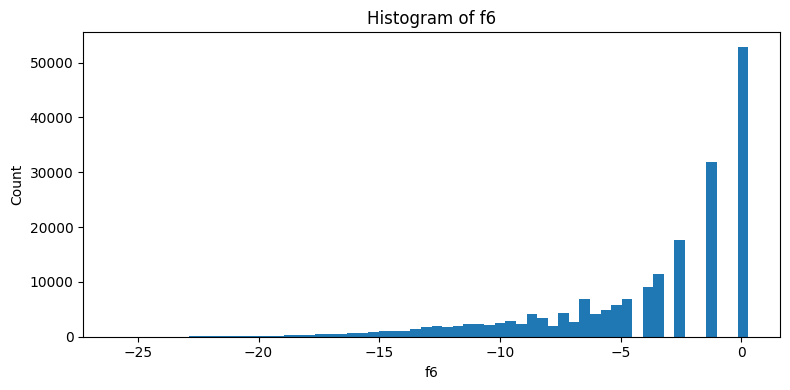

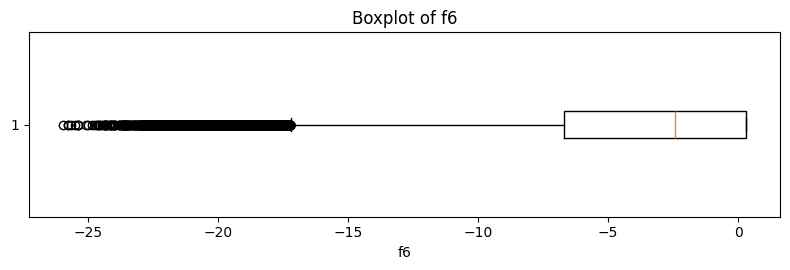

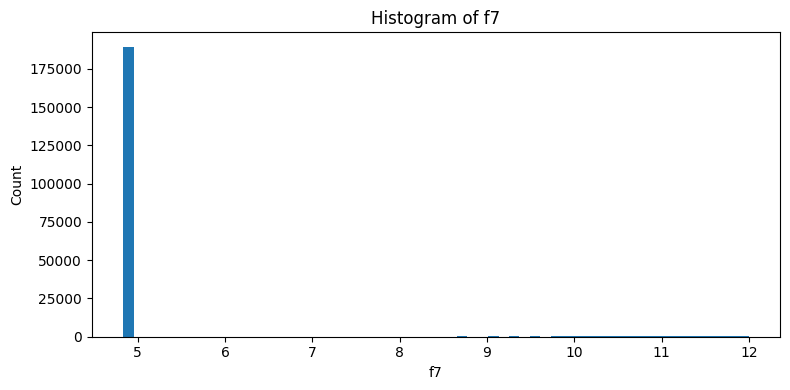

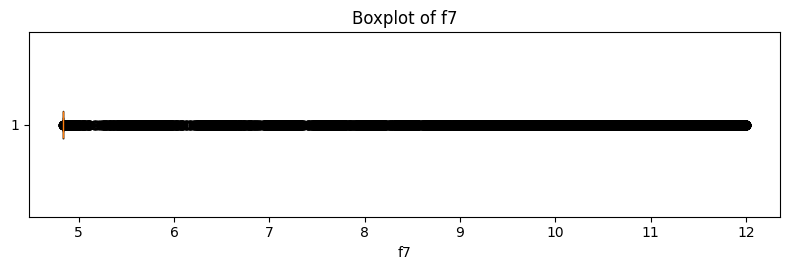

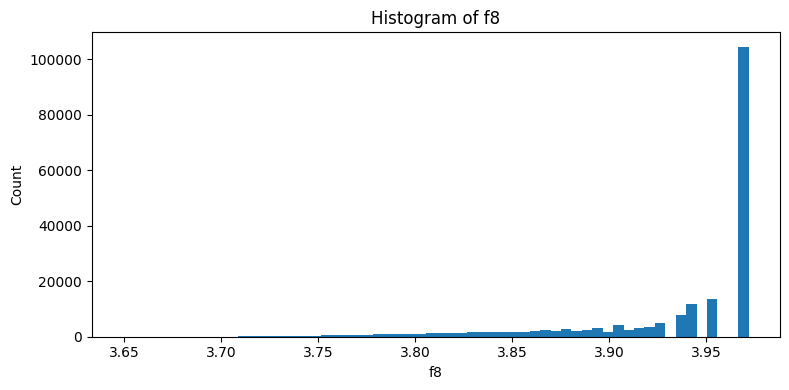

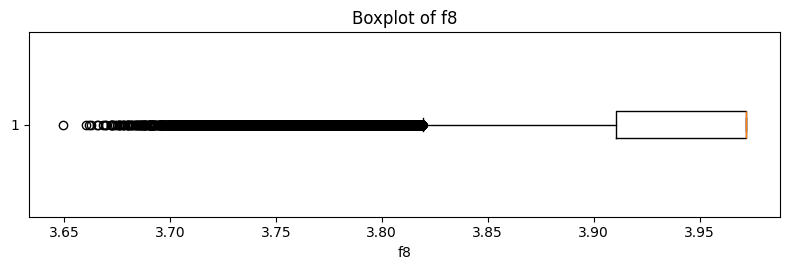

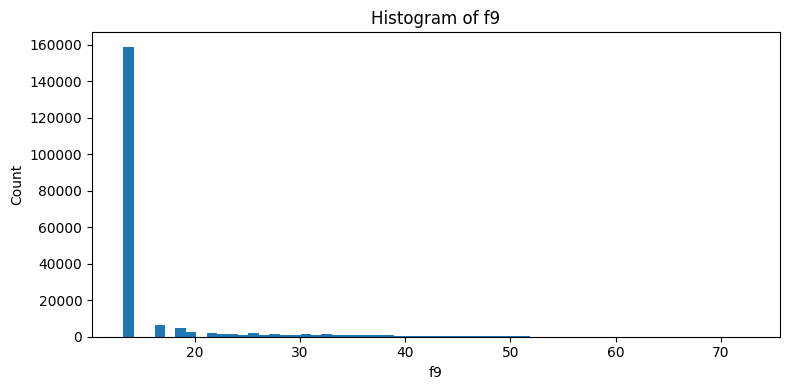

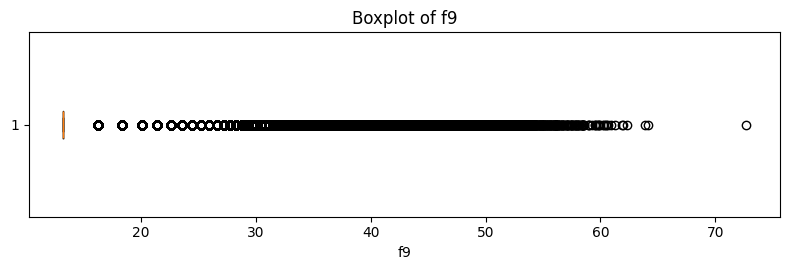

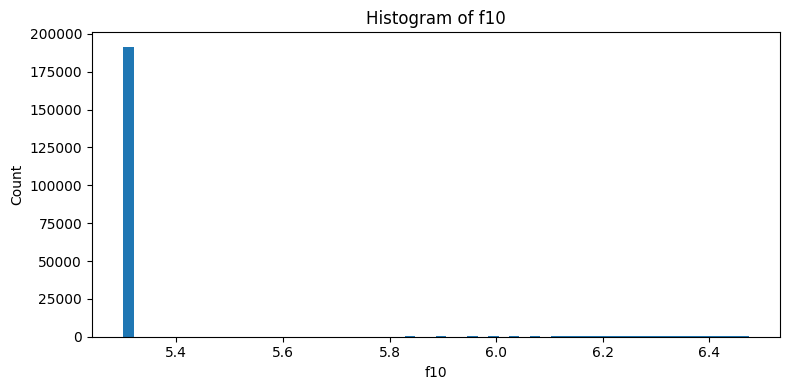

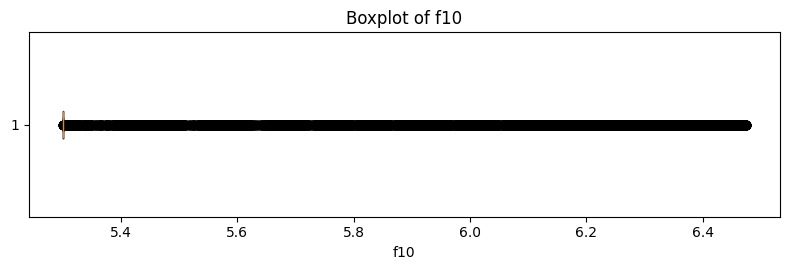

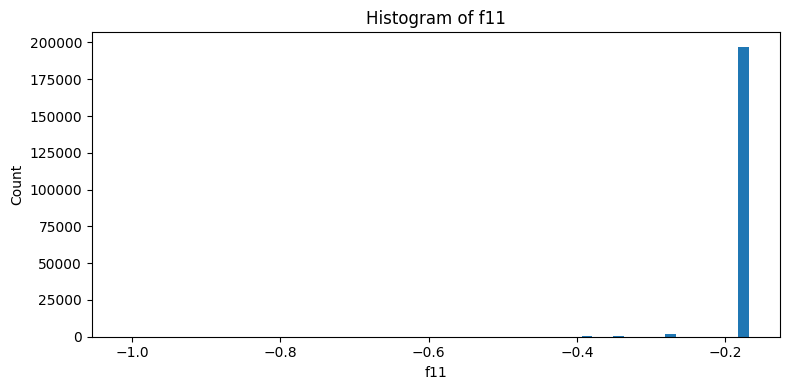

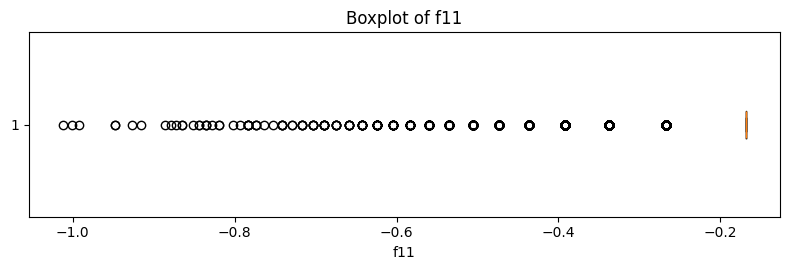

In [31]:
# Sample dùng cho plot để tránh vẽ quá nặng
PLOT_SAMPLE_N = min(len(df), 200_000)
plot_df = df.sample(PLOT_SAMPLE_N, random_state=RANDOM_STATE) if len(df) > PLOT_SAMPLE_N else df.copy()

print("Plot sample shape:", plot_df.shape)


def plot_feature_histogram(dataframe, feature, bins=60):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(dataframe[feature].dropna(), bins=bins)
    ax.set_title(f"Histogram of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_feature_boxplot(dataframe, feature):
    fig, ax = plt.subplots(figsize=(8, 2.8))
    ax.boxplot(dataframe[feature].dropna(), vert=False, showfliers=True)
    ax.set_title(f"Boxplot of {feature}")
    ax.set_xlabel(feature)
    plt.tight_layout()
    plt.show()

# Vẽ tất cả feature. Nếu quá nhiều/khá chậm, đổi thành feature_cols[:3].
FEATURES_TO_PLOT = feature_cols

for feature in FEATURES_TO_PLOT:
    plot_feature_histogram(plot_df, feature)
    plot_feature_boxplot(plot_df, feature)

## 10. So sánh phân phối feature giữa treatment và control

Với uplift dataset, cần kiểm tra treatment/control có cân bằng không. Nếu treatment được random tốt, phân phối feature giữa hai nhóm thường khá giống nhau.

Ta dùng:
- Mean/std theo treatment group.
- **Standardized Mean Difference** — SMD.
- KS statistic nếu có `scipy`.

Quy ước tham khảo thường dùng:
- `abs(SMD) < 0.1`: imbalance nhỏ.
- `abs(SMD) >= 0.1`: nên xem xét kỹ hơn.

,feature,n_treatment,n_control,mean_treatment,mean_control,std_treatment,std_control,smd,abs_smd,ks_statistic,ks_pvalue
3,f3,11882655,2096937,4.169412,4.232821,1.352432,1.242028,-0.048836,0.048836,0.013400,0.000000
6,f6,11882655,2096937,-4.182793,-3.999880,4.600940,4.441985,-0.040448,0.040448,0.013020,0.000000
5,f5,11882655,2096937,4.026602,4.039338,0.437045,0.395538,-0.030557,0.030557,0.007000,0.014823
9,f9,11882655,2096937,16.052589,15.886255,7.056251,6.802162,0.024001,0.024001,0.007050,0.013817
1,f1,11882655,2096937,10.070336,10.067936,0.106693,0.092990,0.023986,0.023986,0.003060,0.736071
8,f8,11882655,2096937,3.933392,3.934652,0.056869,0.055445,-0.022427,0.022427,0.009560,0.000213
7,f7,11882655,2096937,5.105556,5.080285,1.212461,1.163292,0.021269,0.021269,0.007000,0.014823
10,f10,11882655,2096937,5.333661,5.331899,0.168847,0.164676,0.010565,0.010565,0.003680,0.506238
4,f4,11882655,2096937,10.339246,10.336524,0.344117,0.338681,0.007972,0.007972,0.003490,0.575124
0,f0,11882655,2096937,19.614754,19.651705,5.375564,5.388112,-0.006866,0.006866,0.008210,0.002351


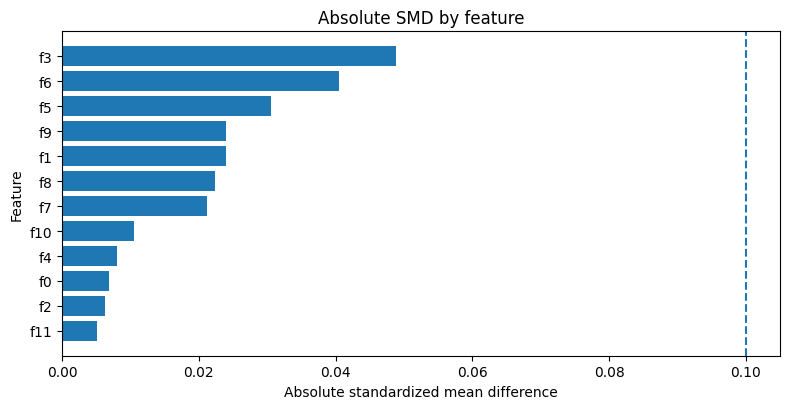

In [32]:
def standardized_mean_difference(dataframe, features, treatment_col="treatment"):
    rows = []
    treated = dataframe[dataframe[treatment_col] == 1]
    control = dataframe[dataframe[treatment_col] == 0]

    for feature in features:
        x_t = treated[feature].dropna()
        x_c = control[feature].dropna()

        mean_t = x_t.mean()
        mean_c = x_c.mean()
        var_t = x_t.var()
        var_c = x_c.var()
        pooled_sd = np.sqrt((var_t + var_c) / 2)

        smd = (mean_t - mean_c) / pooled_sd if pooled_sd and pooled_sd > 0 else np.nan

        row = {
            "feature": feature,
            "n_treatment": len(x_t),
            "n_control": len(x_c),
            "mean_treatment": mean_t,
            "mean_control": mean_c,
            "std_treatment": x_t.std(),
            "std_control": x_c.std(),
            "smd": smd,
            "abs_smd": abs(smd) if pd.notna(smd) else np.nan,
        }

        if SCIPY_AVAILABLE:
            # KS trên sample để tránh quá nặng
            max_ks_n = 100_000
            x_t_ks = x_t.sample(min(len(x_t), max_ks_n), random_state=RANDOM_STATE) if len(x_t) > max_ks_n else x_t
            x_c_ks = x_c.sample(min(len(x_c), max_ks_n), random_state=RANDOM_STATE) if len(x_c) > max_ks_n else x_c
            ks_stat, ks_pvalue = ks_2samp(x_t_ks, x_c_ks)
            row["ks_statistic"] = ks_stat
            row["ks_pvalue"] = ks_pvalue

        rows.append(row)

    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)

if "treatment" in df.columns and feature_cols:
    balance_table = standardized_mean_difference(df, feature_cols, "treatment")
    display(balance_table)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(balance_table))))
    ordered = balance_table.sort_values("abs_smd")
    ax.barh(ordered["feature"], ordered["abs_smd"])
    ax.axvline(0.1, linestyle="--")
    ax.set_title("Absolute SMD by feature")
    ax.set_xlabel("Absolute standardized mean difference")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Cần có cột treatment và feature columns.")

## 11. Overlay histogram: treatment vs control cho từng feature

Bảng SMD cho biết mức imbalance tổng quát, nhưng histogram overlay giúp nhìn trực quan phân phối hai nhóm treatment/control khác nhau ở đâu.

Ta nên vẽ trên sample để notebook chạy nhanh.

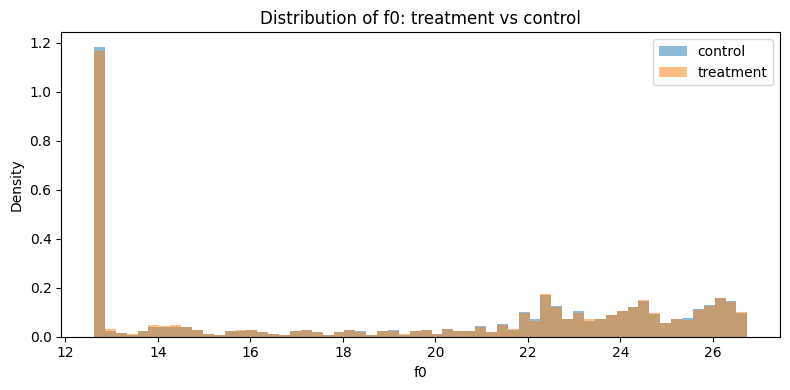

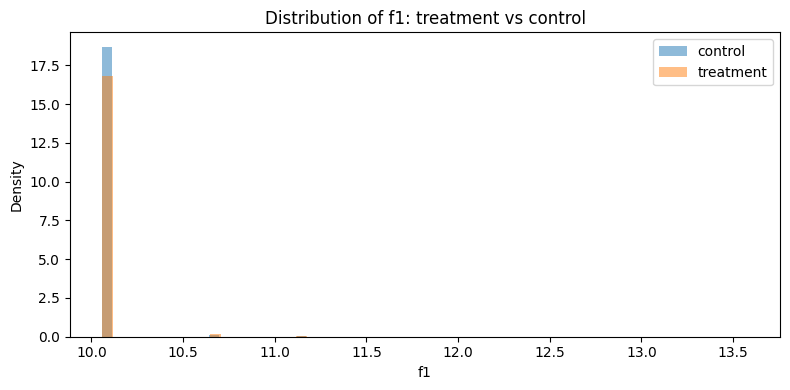

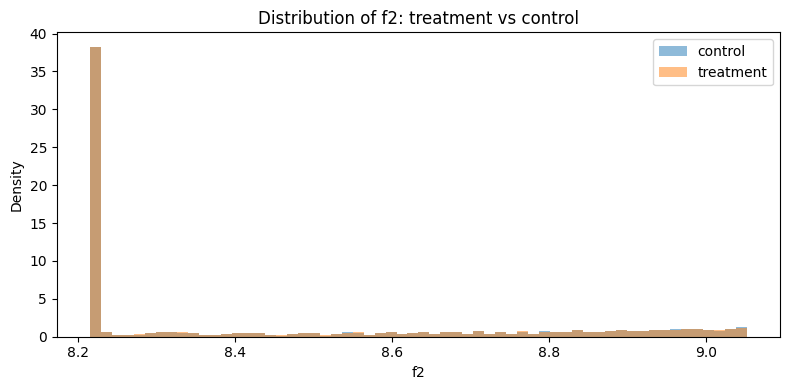

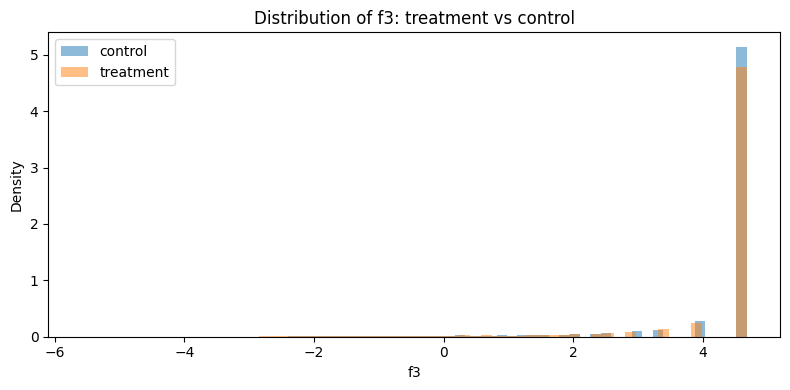

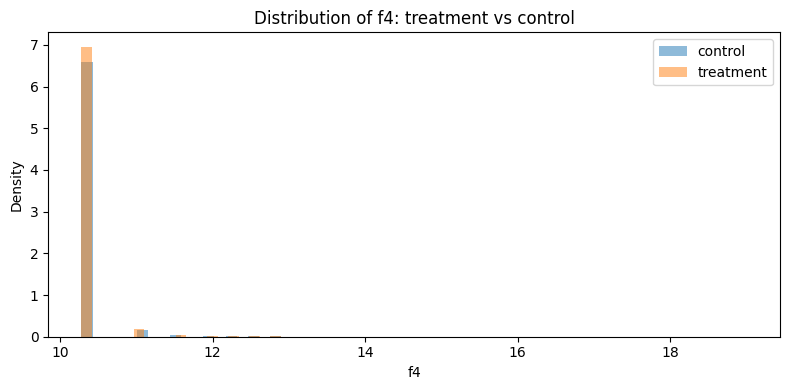

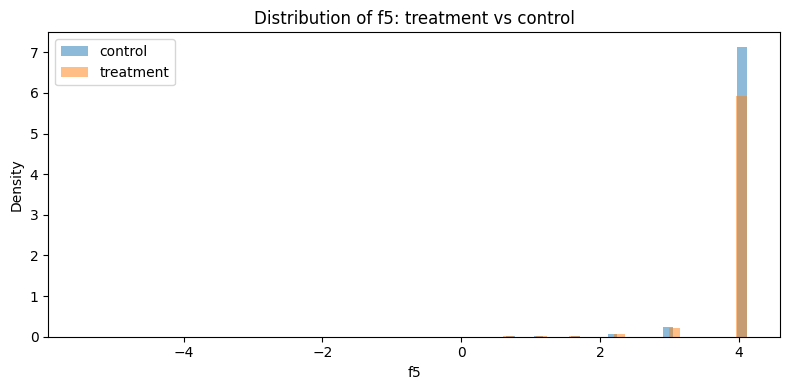

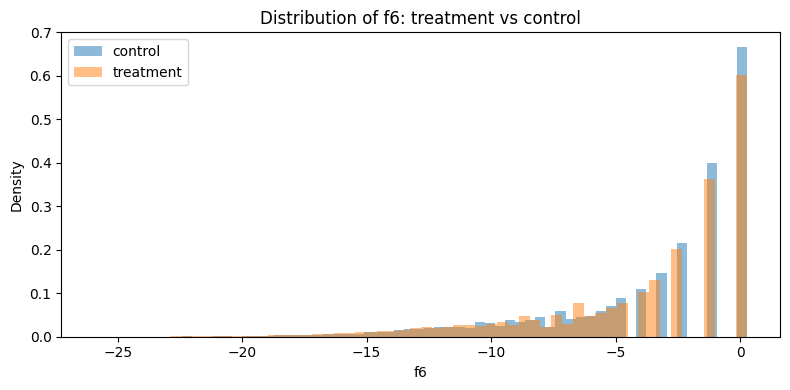

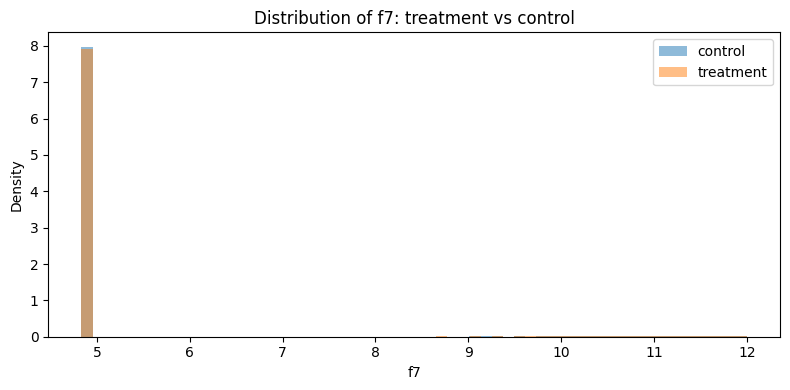

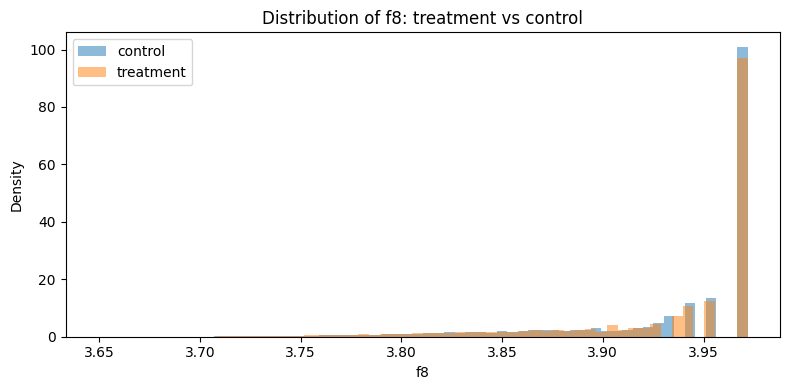

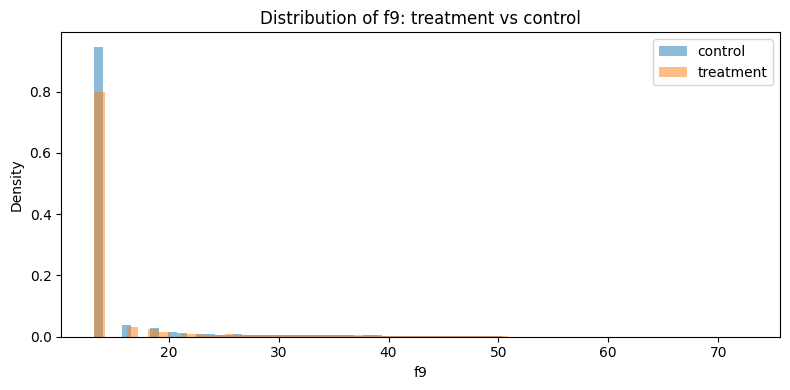

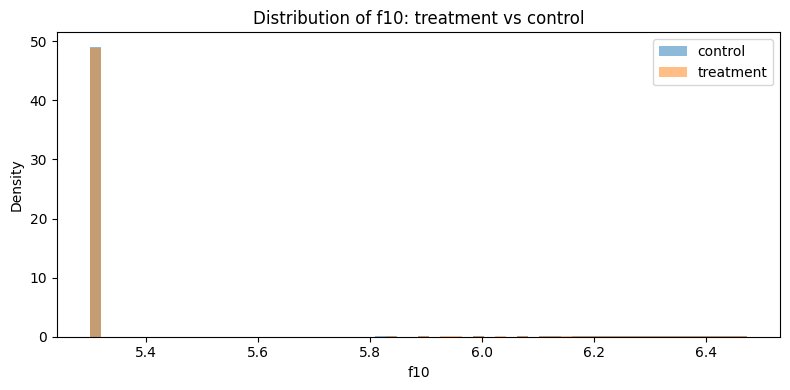

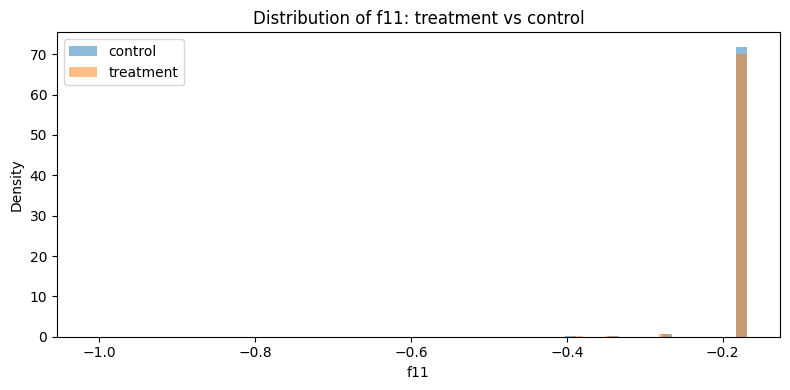

In [33]:
def plot_treatment_control_hist(dataframe, feature, treatment_col="treatment", bins=60):
    tmp = dataframe[[feature, treatment_col]].dropna()
    treated = tmp.loc[tmp[treatment_col] == 1, feature]
    control = tmp.loc[tmp[treatment_col] == 0, feature]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(control, bins=bins, density=True, alpha=0.5, label="control")
    ax.hist(treated, bins=bins, density=True, alpha=0.5, label="treatment")
    ax.set_title(f"Distribution of {feature}: treatment vs control")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()

if "treatment" in plot_df.columns:
    # Nếu quá nhiều biểu đồ, đổi thành feature_cols[:3]
    for feature in feature_cols:
        plot_treatment_control_hist(plot_df, feature, "treatment")
else:
    print("Không có cột treatment.")

## 12. Class imbalance của outcome `visit` và `conversion`

`conversion` thường là rare event. Vì vậy cần xem:
- Positive rate toàn dataset.
- Positive rate theo treatment/control.
- Số lượng positive tuyệt đối, vì rate nhỏ nhưng count lớn vẫn có thể đủ để model học.

,outcome,group,n,positive_count,positive_rate
0,visit,overall,13979592,656929,0.046992
1,visit,treatment=0,2096937,80105,0.038201
2,visit,treatment=1,11882655,576824,0.048543
3,conversion,overall,13979592,40774,0.002917
4,conversion,treatment=0,2096937,4063,0.001938
5,conversion,treatment=1,11882655,36711,0.003089


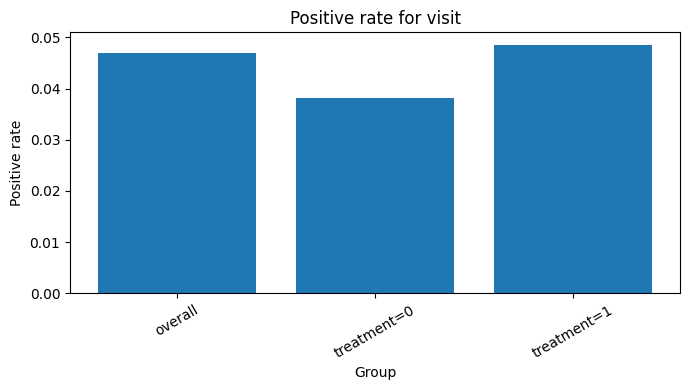

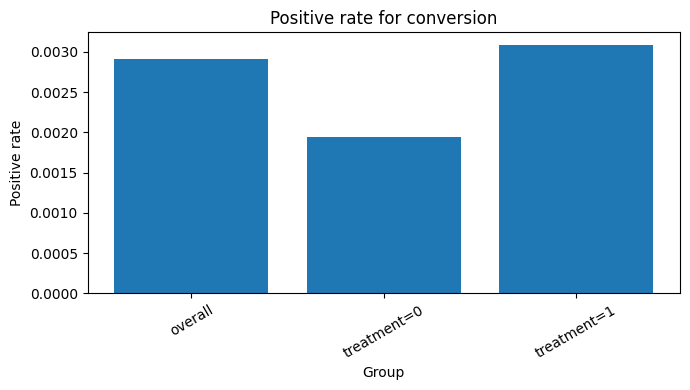

In [34]:
def outcome_imbalance_summary(dataframe, outcomes, treatment_col="treatment"):
    rows = []
    for outcome in outcomes:
        s = dataframe[outcome].dropna()
        rows.append({
            "outcome": outcome,
            "group": "overall",
            "n": len(s),
            "positive_count": s.sum(),
            "positive_rate": s.mean(),
        })

        if treatment_col in dataframe.columns:
            for t_value, g in dataframe.groupby(treatment_col):
                y = g[outcome].dropna()
                rows.append({
                    "outcome": outcome,
                    "group": f"{treatment_col}={t_value}",
                    "n": len(y),
                    "positive_count": y.sum(),
                    "positive_rate": y.mean(),
                })

    return pd.DataFrame(rows)

imbalance_table = outcome_imbalance_summary(df, outcome_cols, "treatment")
display(imbalance_table)

# Plot positive rate
if len(imbalance_table) > 0:
    for outcome in outcome_cols:
        tmp = imbalance_table[imbalance_table["outcome"] == outcome]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(tmp["group"], tmp["positive_rate"])
        ax.set_title(f"Positive rate for {outcome}")
        ax.set_xlabel("Group")
        ax.set_ylabel("Positive rate")
        ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()

## 13. Feature vs outcome: dùng binned target rate thay cho scatter plot thô

Scatter plot giữa feature numeric và target binary (`0/1`) thường khó đọc vì điểm chỉ nằm trên 2 đường ngang. Cách tốt hơn:

- Chia feature thành quantile bins.
- Tính `visit rate` hoặc `conversion rate` trong từng bin.
- Vẽ rate theo bin.

Cách này cho thấy feature có liên quan tới xác suất outcome hay không.

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(12.615, 13.927]",4193882,12.684774,0.004215,17677,0,"(12.615, 13.927]"
1,"(13.927, 18.127]",1397955,15.649049,0.009613,13438,1,"(13.927, 18.127]"
2,"(18.127, 21.923]",1397959,20.423620,0.003893,5442,2,"(18.127, 21.923]"
3,"(21.923, 22.771]",1397962,22.391775,0.000638,892,3,"(21.923, 22.771]"
4,"(22.771, 24.009]",1397958,23.402424,0.001016,1421,4,"(22.771, 24.009]"
5,"(24.009, 24.833]",1397957,24.430878,0.000488,682,5,"(24.009, 24.833]"
6,"(24.833, 25.991]",1397959,25.515844,0.000574,802,6,"(24.833, 25.991]"
7,"(25.991, 26.745]",1397960,26.335068,0.000300,420,7,"(25.991, 26.745]"


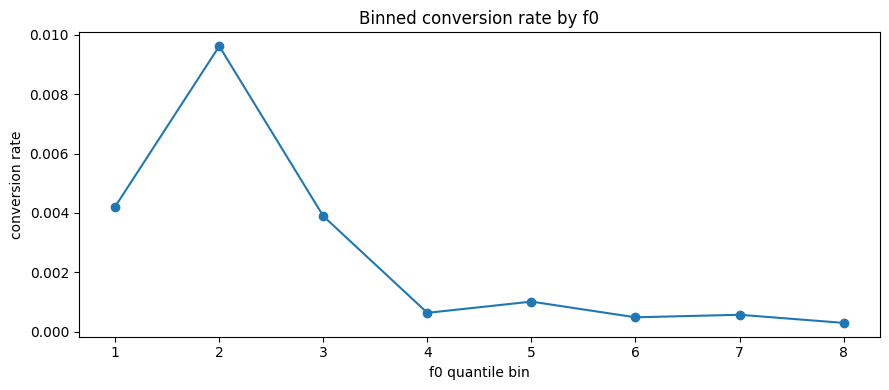

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(10.059000000000001, 16.344]",13979592,10.069976,0.002917,40774,0,"(10.059000000000001, 16.344]"


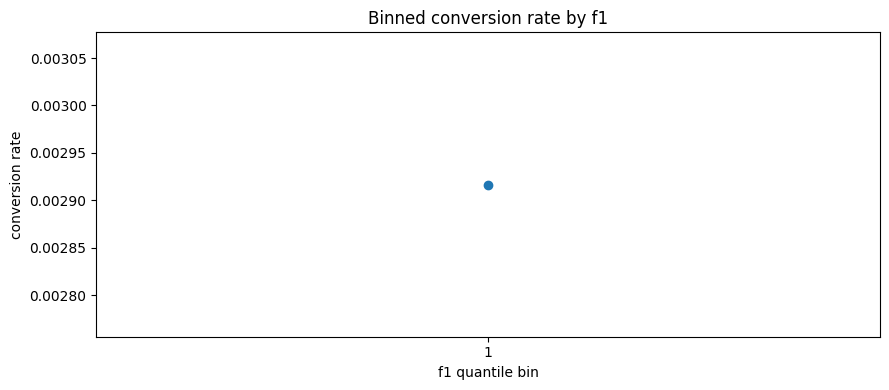

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(8.213000000000001, 8.382]",8387755,8.224252,0.003294,27631,0,"(8.213000000000001, 8.382]"
1,"(8.382, 8.629]",1397959,8.507961,0.006415,8968,1,"(8.382, 8.629]"
2,"(8.629, 8.815]",1397973,8.723681,0.001897,2652,2,"(8.629, 8.815]"
3,"(8.815, 8.951]",1397956,8.885835,0.000748,1045,3,"(8.815, 8.951]"
4,"(8.951, 9.052]",1397949,9.002839,0.000342,478,4,"(8.951, 9.052]"


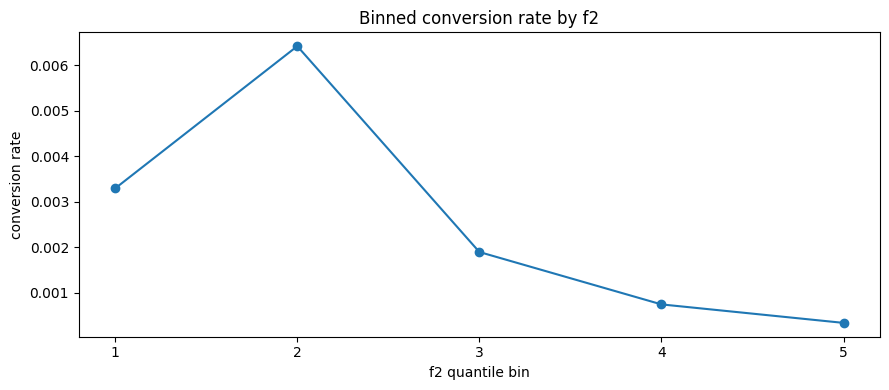

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(-8.399, 2.588]",1438421,0.663181,0.015780,22698,0,"(-8.399, 2.588]"
1,"(2.588, 4.68]",12541171,4.582164,0.001441,18076,1,"(2.588, 4.68]"


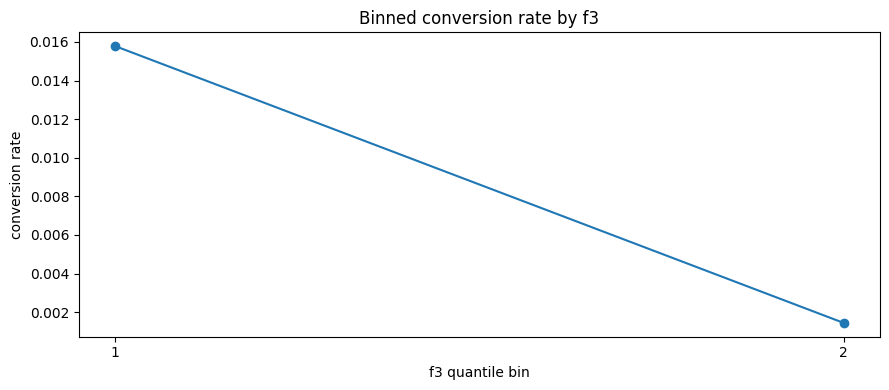

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(10.280000000000001, 21.124]",13979592,10.338837,0.002917,40774,0,"(10.280000000000001, 21.124]"


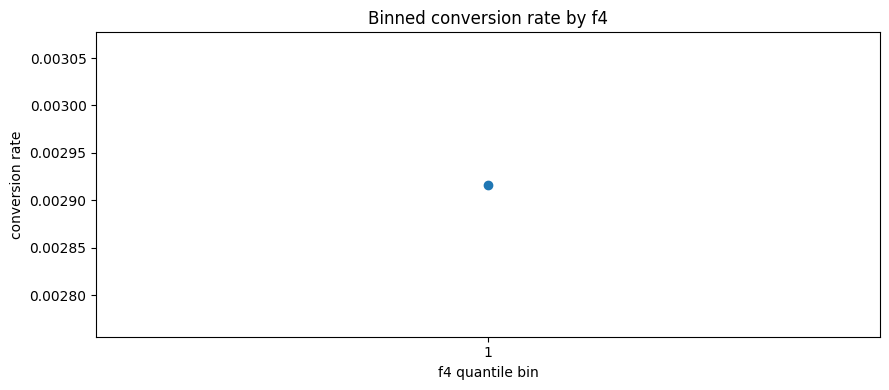

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(-9.013, 4.115]",13979592,4.028512,0.002917,40774,0,"(-9.013, 4.115]"


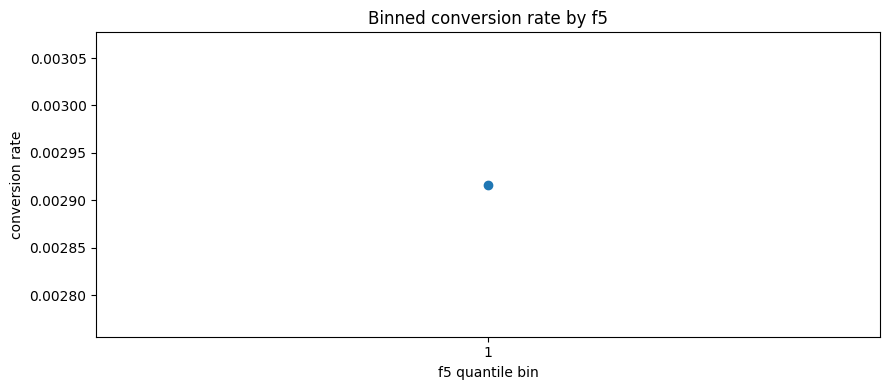

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(-31.431, -10.988]",1428267,-14.021983,0.014221,20311,0,"(-31.431, -10.988]"
1,"(-10.988, -7.822]",1478402,-9.203830,0.003672,5429,1,"(-10.988, -7.822]"
2,"(-7.822, -5.576]",1603065,-6.449891,0.001995,3198,2,"(-7.822, -5.576]"
3,"(-5.576, -3.994]",1501052,-4.485928,0.001320,1981,3,"(-5.576, -3.994]"
4,"(-3.994, -2.411]",2030779,-2.756600,0.000884,1795,4,"(-3.994, -2.411]"
5,"(-2.411, -1.288]",2232482,-1.288207,0.000605,1350,5,"(-2.411, -1.288]"
6,"(-1.288, 0.294]",3705545,0.294443,0.001811,6710,6,"(-1.288, 0.294]"


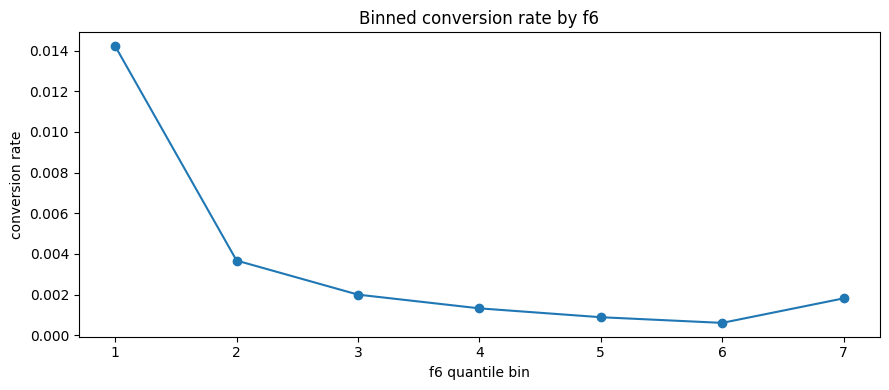

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(4.832999999999999, 11.998]",13979592,5.101765,0.002917,40774,0,"(4.832999999999999, 11.998]"


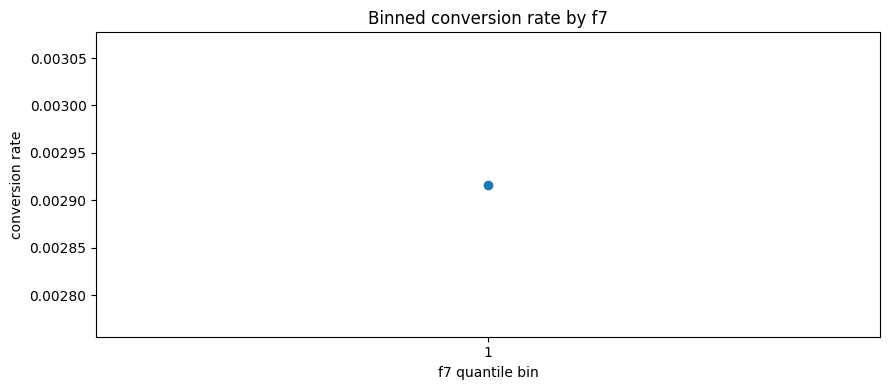

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(3.634, 3.843]",1406431,3.799504,0.023110,32502,0,"(3.634, 3.843]"
1,"(3.843, 3.893]",1442375,3.870518,0.003597,5188,1,"(3.843, 3.893]"
2,"(3.893, 3.927]",1504765,3.913723,0.001065,1603,2,"(3.893, 3.927]"
3,"(3.927, 3.944]",1366697,3.940169,0.000389,531,3,"(3.927, 3.944]"
4,"(3.944, 3.972]",8259324,3.969953,0.000115,950,4,"(3.944, 3.972]"


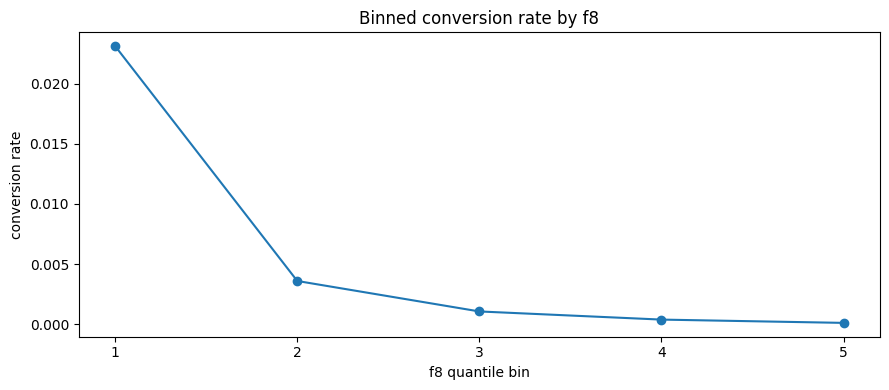

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(13.189, 16.226]",11568147,13.309419,0.000391,4523,0,"(13.189, 16.226]"
1,"(16.226, 25.241]",1031772,20.965776,0.003370,3477,1,"(16.226, 25.241]"
2,"(25.241, 75.295]",1379673,35.126171,0.023755,32774,2,"(25.241, 75.295]"


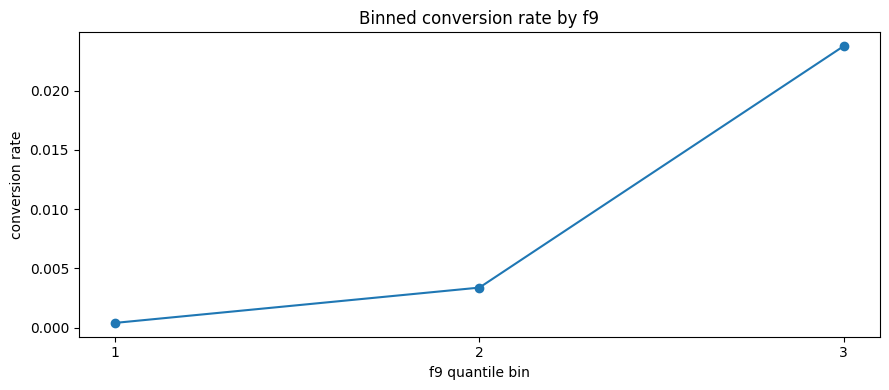

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(5.2989999999999995, 6.474]",13979592,5.333395,0.002917,40774,0,"(5.2989999999999995, 6.474]"


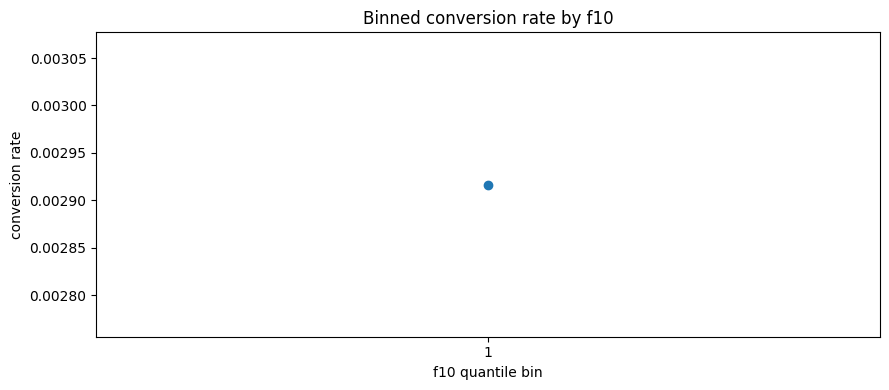

,bin,n,feature_mean,outcome_rate,positive_count,bin_id,bin_label
0,"(-1.3849999999999998, -0.169]",13979592,-0.170967,0.002917,40774,0,"(-1.3849999999999998, -0.169]"


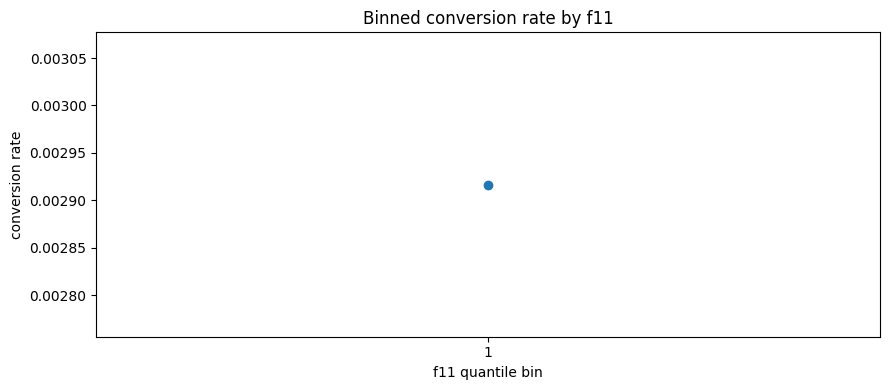

In [35]:
def safe_quantile_bin(series, q=10):
    """Tạo quantile bins. Nếu qcut lỗi do quá nhiều giá trị trùng, fallback sang cut."""
    s = series.copy()
    try:
        return pd.qcut(s, q=q, duplicates="drop")
    except Exception:
        return pd.cut(s, bins=q, duplicates="drop")


def binned_outcome_rate(dataframe, feature, outcome, q=10):
    tmp = dataframe[[feature, outcome]].dropna().copy()
    tmp["bin"] = safe_quantile_bin(tmp[feature], q=q)

    result = tmp.groupby("bin", observed=True).agg(
        n=(outcome, "size"),
        feature_mean=(feature, "mean"),
        outcome_rate=(outcome, "mean"),
        positive_count=(outcome, "sum")
    ).reset_index()

    result["bin_id"] = np.arange(len(result))
    result["bin_label"] = result["bin"].astype(str)
    return result


def plot_binned_outcome_rate(result, feature, outcome):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(result["bin_id"], result["outcome_rate"], marker="o")
    ax.set_title(f"Binned {outcome} rate by {feature}")
    ax.set_xlabel(f"{feature} quantile bin")
    ax.set_ylabel(f"{outcome} rate")
    ax.set_xticks(result["bin_id"])
    ax.set_xticklabels(result["bin_id"] + 1)
    plt.tight_layout()
    plt.show()

# Chọn target chính để explore. Có thể đổi thành "visit".
PRIMARY_OUTCOME = "conversion" if "conversion" in outcome_cols else (outcome_cols[0] if outcome_cols else None)

if PRIMARY_OUTCOME is not None:
    binned_tables = {}
    for feature in feature_cols:
        result = binned_outcome_rate(df, feature, PRIMARY_OUTCOME, q=10)
        binned_tables[(feature, PRIMARY_OUTCOME)] = result
        display(result.head(20))
        plot_binned_outcome_rate(result, feature, PRIMARY_OUTCOME)
else:
    print("Không tìm thấy outcome columns.")

## 14. Feature vs outcome theo treatment/control

Mục này mở rộng phần trước: thay vì chỉ xem outcome rate chung, ta xem riêng:

- Outcome rate trong treatment group.
- Outcome rate trong control group.

Đây là bước chuẩn bị để tính uplift theo feature bins.

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(12.615, 13.927]",0,631981,0.002810,1776,12.674968,"(12.615, 13.927]"
1,"(12.615, 13.927]",1,3561901,0.004464,15901,12.686514,"(12.615, 13.927]"
2,"(13.927, 18.127]",0,199106,0.006092,1213,15.674689,"(13.927, 18.127]"
3,"(13.927, 18.127]",1,1198849,0.010197,12225,15.644791,"(13.927, 18.127]"
4,"(18.127, 21.923]",0,209046,0.002722,569,20.430056,"(18.127, 21.923]"
5,"(18.127, 21.923]",1,1188913,0.004099,4873,20.422489,"(18.127, 21.923]"
6,"(21.923, 22.771]",0,209933,0.000443,93,22.390913,"(21.923, 22.771]"
7,"(21.923, 22.771]",1,1188029,0.000673,799,22.391928,"(21.923, 22.771]"
8,"(22.771, 24.009]",0,211233,0.000819,173,23.403786,"(22.771, 24.009]"
9,"(22.771, 24.009]",1,1186725,0.001052,1248,23.402182,"(22.771, 24.009]"


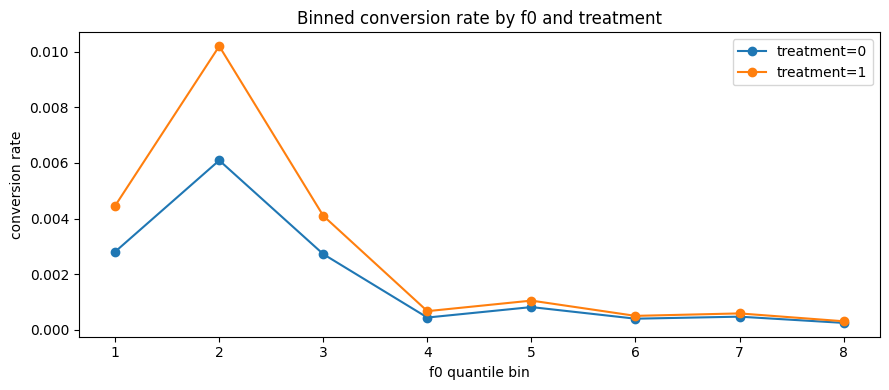

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(10.059000000000001, 16.344]",0,2096937,0.001938,4063,10.067935,"(10.059000000000001, 16.344]"
1,"(10.059000000000001, 16.344]",1,11882655,0.003089,36711,10.070336,"(10.059000000000001, 16.344]"


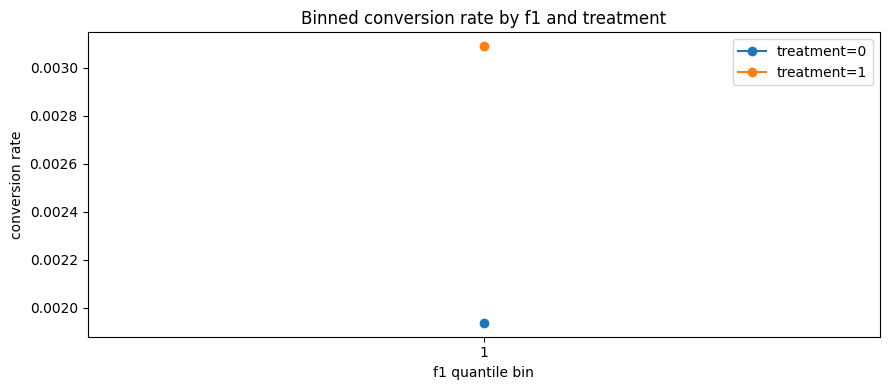

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(8.213000000000001, 8.382]",0,1255172,0.002224,2792,8.223821,"(8.213000000000001, 8.382]"
1,"(8.213000000000001, 8.382]",1,7132583,0.003482,24839,8.224328,"(8.213000000000001, 8.382]"
2,"(8.382, 8.629]",0,206420,0.004253,878,8.508900,"(8.382, 8.629]"
3,"(8.382, 8.629]",1,1191539,0.006790,8090,8.507798,"(8.382, 8.629]"
4,"(8.629, 8.815]",0,209583,0.001121,235,8.723715,"(8.629, 8.815]"
5,"(8.629, 8.815]",1,1188390,0.002034,2417,8.723676,"(8.629, 8.815]"
6,"(8.815, 8.951]",0,212407,0.000537,114,8.885891,"(8.815, 8.951]"
7,"(8.815, 8.951]",1,1185549,0.000785,931,8.885825,"(8.815, 8.951]"
8,"(8.951, 9.052]",0,213355,0.000206,44,9.002851,"(8.951, 9.052]"
9,"(8.951, 9.052]",1,1184594,0.000366,434,9.002837,"(8.951, 9.052]"


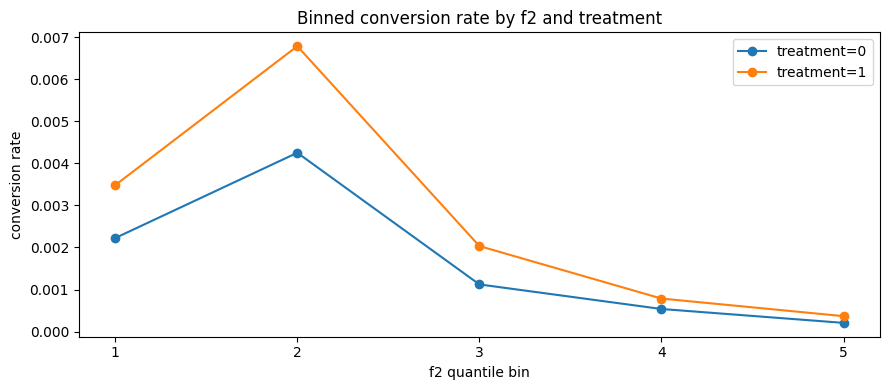

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(-8.399, 2.588]",0,193472,0.010136,1961,0.767912,"(-8.399, 2.588]"
1,"(-8.399, 2.588]",1,1244949,0.016657,20737,0.646905,"(-8.399, 2.588]"
2,"(2.588, 4.68]",0,1903465,0.001104,2102,4.585001,"(2.588, 4.68]"
3,"(2.588, 4.68]",1,10637706,0.001502,15974,4.581656,"(2.588, 4.68]"


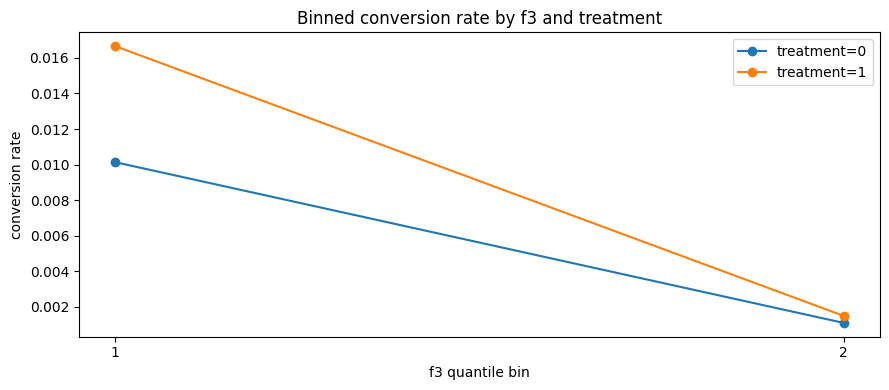

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(10.280000000000001, 21.124]",0,2096937,0.001938,4063,10.336526,"(10.280000000000001, 21.124]"
1,"(10.280000000000001, 21.124]",1,11882655,0.003089,36711,10.339245,"(10.280000000000001, 21.124]"


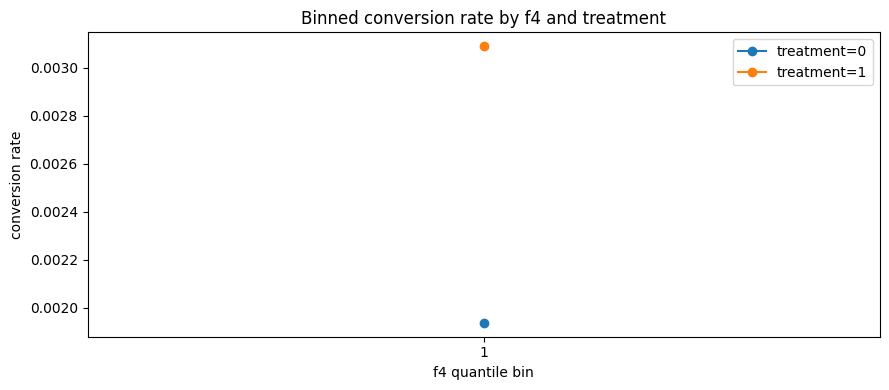

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(-9.013, 4.115]",0,2096937,0.001938,4063,4.039339,"(-9.013, 4.115]"
1,"(-9.013, 4.115]",1,11882655,0.003089,36711,4.026602,"(-9.013, 4.115]"


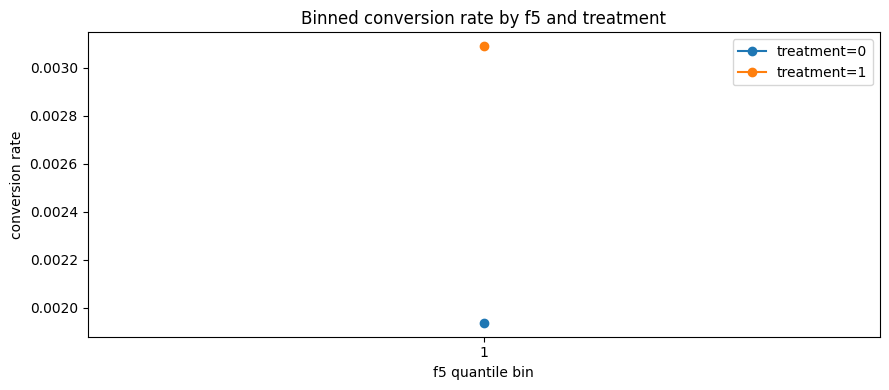

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(-31.431, -10.988]",0,195051,0.008987,1753,-13.849216,"(-31.431, -10.988]"
1,"(-31.431, -10.988]",1,1233216,0.015048,18558,-14.049309,"(-31.431, -10.988]"
2,"(-10.988, -7.822]",0,218475,0.002504,547,-9.200011,"(-10.988, -7.822]"
3,"(-10.988, -7.822]",1,1259927,0.003875,4882,-9.204492,"(-10.988, -7.822]"
4,"(-7.822, -5.576]",0,240075,0.001337,321,-6.446789,"(-7.822, -5.576]"
5,"(-7.822, -5.576]",1,1362990,0.002111,2877,-6.450438,"(-7.822, -5.576]"
6,"(-5.576, -3.994]",0,226395,0.000936,212,-4.484138,"(-5.576, -3.994]"
7,"(-5.576, -3.994]",1,1274657,0.001388,1769,-4.486246,"(-5.576, -3.994]"
8,"(-3.994, -2.411]",0,306763,0.000704,216,-2.757036,"(-3.994, -2.411]"
9,"(-3.994, -2.411]",1,1724016,0.000916,1579,-2.756523,"(-3.994, -2.411]"


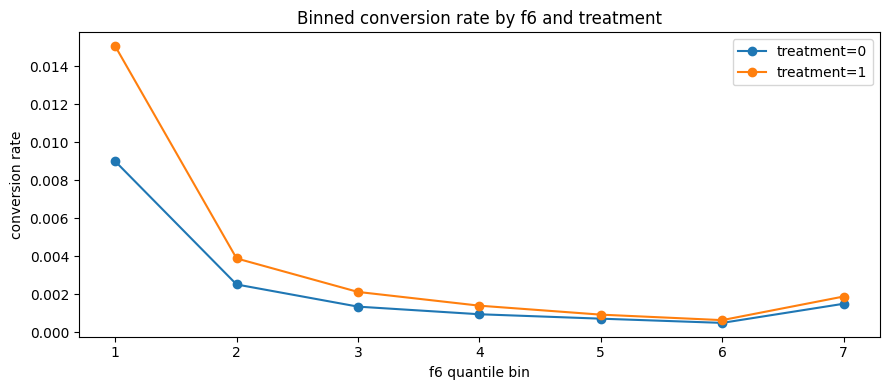

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(4.832999999999999, 11.998]",0,2096937,0.001938,4063,5.080284,"(4.832999999999999, 11.998]"
1,"(4.832999999999999, 11.998]",1,11882655,0.003089,36711,5.105555,"(4.832999999999999, 11.998]"


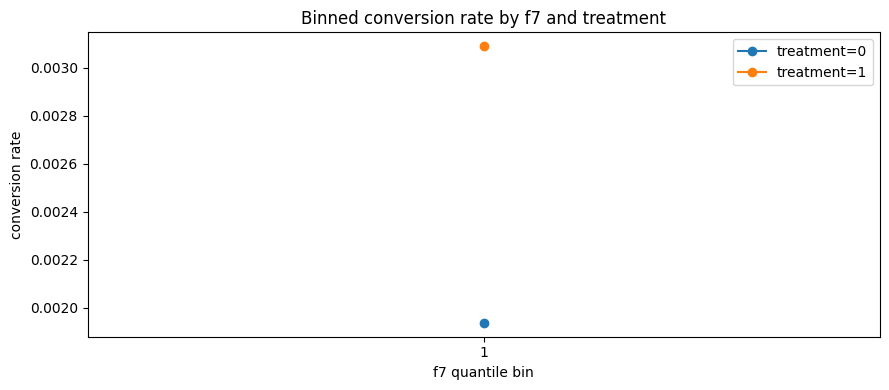

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(3.634, 3.843]",0,198658,0.016330,3244,3.800259,"(3.634, 3.843]"
1,"(3.634, 3.843]",1,1207773,0.024225,29258,3.799380,"(3.634, 3.843]"
2,"(3.843, 3.893]",0,214076,0.002406,515,3.870663,"(3.843, 3.893]"
3,"(3.843, 3.893]",1,1228299,0.003804,4673,3.870493,"(3.843, 3.893]"
4,"(3.893, 3.927]",0,227365,0.000699,159,3.913769,"(3.893, 3.927]"
5,"(3.893, 3.927]",1,1277400,0.001130,1444,3.913715,"(3.893, 3.927]"
6,"(3.927, 3.944]",0,210064,0.000243,51,3.940175,"(3.927, 3.944]"
7,"(3.927, 3.944]",1,1156633,0.000415,480,3.940167,"(3.927, 3.944]"
8,"(3.944, 3.972]",0,1246774,0.000075,94,3.969930,"(3.944, 3.972]"
9,"(3.944, 3.972]",1,7012550,0.000122,856,3.969957,"(3.944, 3.972]"


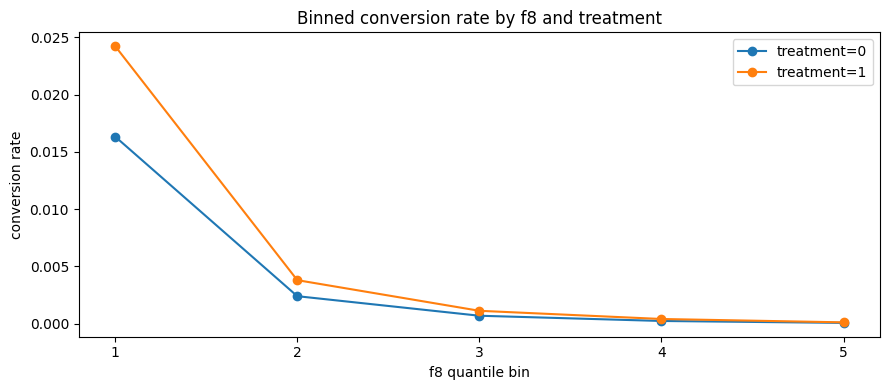

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(13.189, 16.226]",0,1747126,0.000248,433,13.309382,"(13.189, 16.226]"
1,"(13.189, 16.226]",1,9821021,0.000416,4090,13.309425,"(13.189, 16.226]"
2,"(16.226, 25.241]",0,154652,0.002347,363,20.935198,"(16.226, 25.241]"
3,"(16.226, 25.241]",1,877120,0.003550,3114,20.971169,"(16.226, 25.241]"
4,"(25.241, 75.295]",0,195159,0.016740,3267,34.954231,"(25.241, 75.295]"
5,"(25.241, 75.295]",1,1184514,0.024911,29507,35.154503,"(25.241, 75.295]"


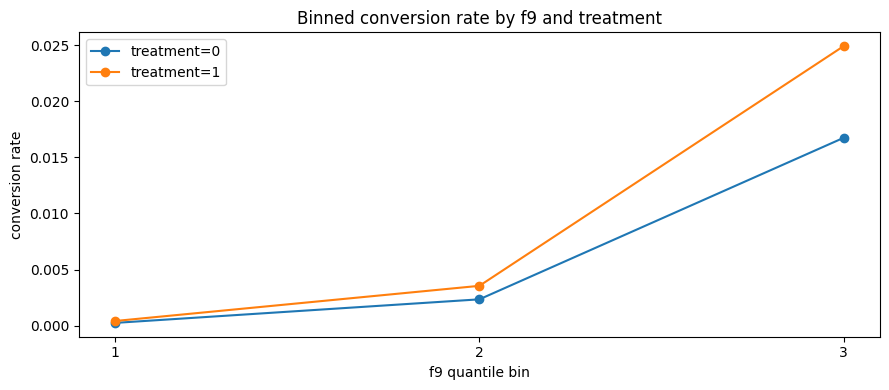

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(5.2989999999999995, 6.474]",0,2096937,0.001938,4063,5.331898,"(5.2989999999999995, 6.474]"
1,"(5.2989999999999995, 6.474]",1,11882655,0.003089,36711,5.333660,"(5.2989999999999995, 6.474]"


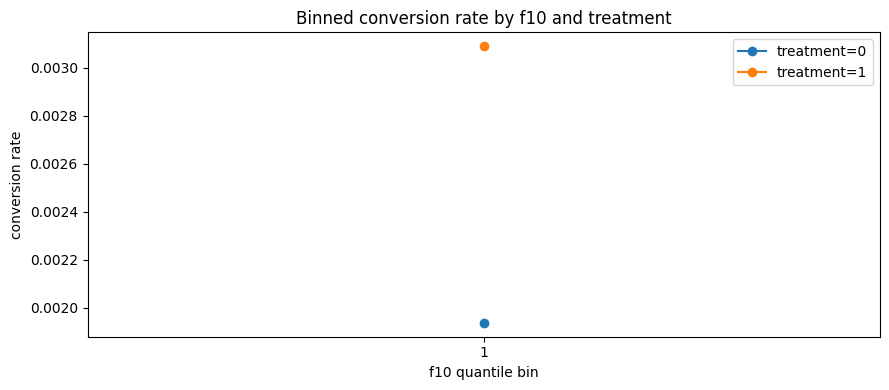

,bin,treatment,n,outcome_rate,positive_count,feature_mean,bin_label
0,"(-1.3849999999999998, -0.169]",0,2096937,0.001938,4063,-0.170868,"(-1.3849999999999998, -0.169]"
1,"(-1.3849999999999998, -0.169]",1,11882655,0.003089,36711,-0.170985,"(-1.3849999999999998, -0.169]"


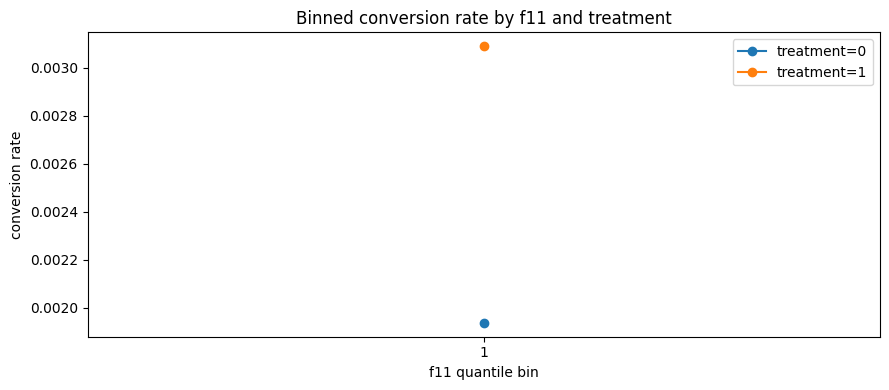

In [36]:
def binned_outcome_rate_by_treatment(dataframe, feature, outcome, treatment_col="treatment", q=10):
    tmp = dataframe[[feature, outcome, treatment_col]].dropna().copy()
    tmp["bin"] = safe_quantile_bin(tmp[feature], q=q)

    result = tmp.groupby(["bin", treatment_col], observed=True).agg(
        n=(outcome, "size"),
        outcome_rate=(outcome, "mean"),
        positive_count=(outcome, "sum"),
        feature_mean=(feature, "mean")
    ).reset_index()

    result["bin_label"] = result["bin"].astype(str)
    return result


def plot_binned_rate_by_treatment(result, feature, outcome, treatment_col="treatment"):
    fig, ax = plt.subplots(figsize=(9, 4))

    bins = list(result["bin"].drop_duplicates())
    bin_map = {b: i for i, b in enumerate(bins)}

    for t_value, g in result.groupby(treatment_col):
        x = g["bin"].map(bin_map)
        ax.plot(x, g["outcome_rate"], marker="o", label=f"{treatment_col}={t_value}")

    ax.set_title(f"Binned {outcome} rate by {feature} and treatment")
    ax.set_xlabel(f"{feature} quantile bin")
    ax.set_ylabel(f"{outcome} rate")
    ax.set_xticks(range(len(bins)))
    ax.set_xticklabels([str(i + 1) for i in range(len(bins))])
    ax.legend()
    plt.tight_layout()
    plt.show()

if "treatment" in df.columns and PRIMARY_OUTCOME is not None:
    rate_by_treatment_tables = {}
    for feature in feature_cols:
        result = binned_outcome_rate_by_treatment(df, feature, PRIMARY_OUTCOME, "treatment", q=10)
        rate_by_treatment_tables[(feature, PRIMARY_OUTCOME)] = result
        display(result.head(30))
        plot_binned_rate_by_treatment(result, feature, PRIMARY_OUTCOME, "treatment")
else:
    print("Cần có cột treatment và outcome.")

## 15. Uplift theo feature bins

Đây là một trong những phần quan trọng nhất cho Criteo Uplift Dataset.

Với mỗi feature:

1. Chia feature thành quantile bins.
2. Trong từng bin, tính:
   - `rate_treatment = P(Y=1 | T=1, bin)`
   - `rate_control = P(Y=1 | T=0, bin)`
   - `uplift = rate_treatment - rate_control`
3. Vẽ uplift theo bin.

Nếu uplift thay đổi mạnh giữa các bin, đó là dấu hiệu có **heterogeneous treatment effect**.

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,12.680740,0.004464,0.002810,3561901,631981,15901,1776,0.001654,0.588560,0,"(12.615, 13.927]"
1,15.659740,0.010197,0.006092,1198849,199106,12225,1213,0.004105,0.673817,1,"(13.927, 18.127]"
2,20.426273,0.004099,0.002722,1188913,209046,4873,569,0.001377,0.505830,2,"(18.127, 21.923]"
3,22.391420,0.000673,0.000443,1188029,209933,799,93,0.000230,0.518160,3,"(21.923, 22.771]"
4,23.402985,0.001052,0.000819,1186725,211233,1248,173,0.000233,0.284045,4,"(22.771, 24.009]"
5,24.431023,0.000503,0.000402,1186435,211522,597,85,0.000101,0.252181,5,"(24.009, 24.833]"
6,25.514793,0.000592,0.000474,1185084,212875,701,101,0.000117,0.246729,6,"(24.833, 25.991]"
7,26.335323,0.000309,0.000251,1186719,211241,367,53,0.000058,0.232595,7,"(25.991, 26.745]"


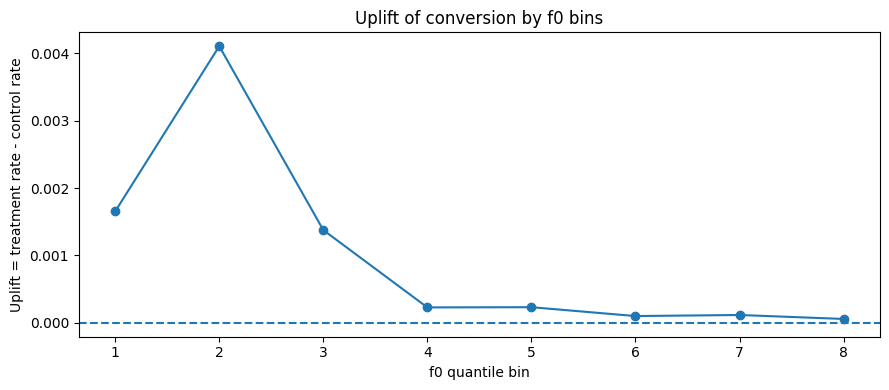

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,10.069136,0.003089,0.001938,11882655,2096937,36711,4063,0.001152,0.594488,0,"(10.059000000000001, 16.344]"


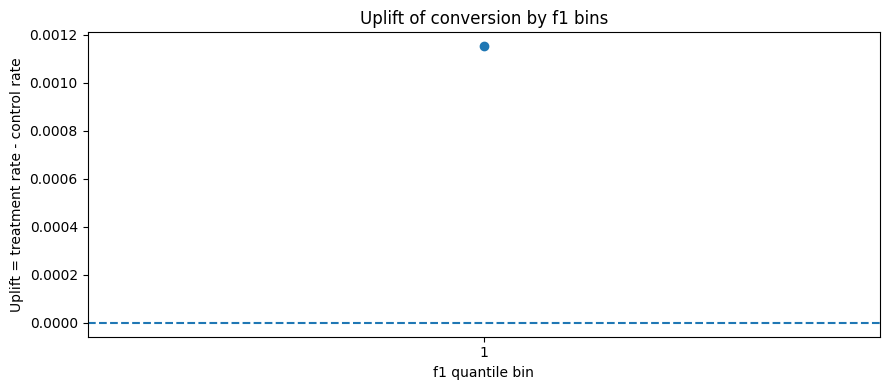

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,8.224074,0.003482,0.002224,7132583,1255172,24839,2792,0.001258,0.565579,0,"(8.213000000000001, 8.382]"
1,8.508348,0.006790,0.004253,1191539,206420,8090,878,0.002536,0.596238,1,"(8.382, 8.629]"
2,8.723696,0.002034,0.001121,1188390,209583,2417,235,0.000913,0.813869,2,"(8.629, 8.815]"
3,8.885859,0.000785,0.000537,1185549,212407,931,114,0.000249,0.463168,3,"(8.815, 8.951]"
4,9.002844,0.000366,0.000206,1184594,213355,434,44,0.000160,0.776521,4,"(8.951, 9.052]"


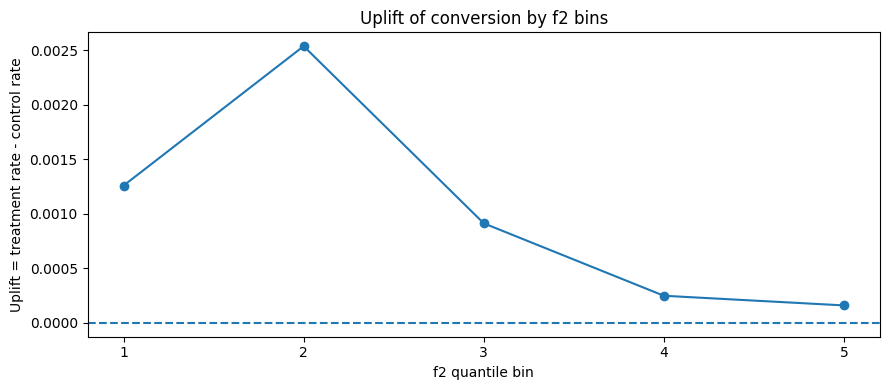

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,0.707408,0.016657,0.010136,1244949,193472,20737,1961,0.006521,0.643368,0,"(-8.399, 2.588]"
1,4.583329,0.001502,0.001104,10637706,1903465,15974,2102,0.000397,0.359809,1,"(2.588, 4.68]"


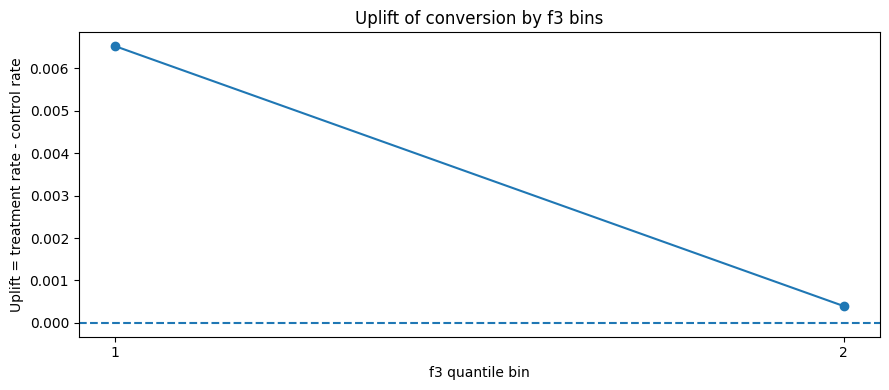

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,10.337885,0.003089,0.001938,11882655,2096937,36711,4063,0.001152,0.594488,0,"(10.280000000000001, 21.124]"


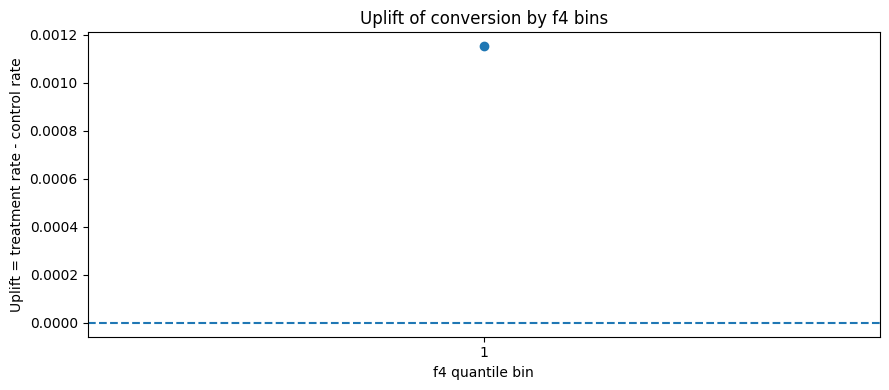

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,4.032970,0.003089,0.001938,11882655,2096937,36711,4063,0.001152,0.594488,0,"(-9.013, 4.115]"


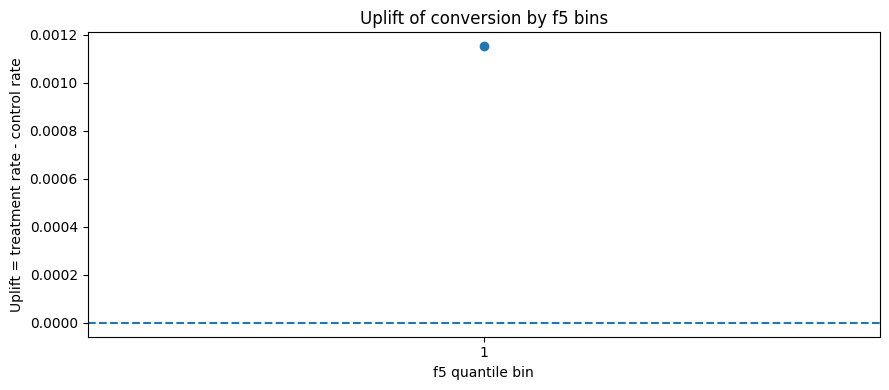

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,-13.949263,0.015048,0.008987,1233216,195051,18558,1753,0.006061,0.674396,0,"(-31.431, -10.988]"
1,-9.202251,0.003875,0.002504,1259927,218475,4882,547,0.001371,0.547629,1,"(-10.988, -7.822]"
2,-6.448613,0.002111,0.001337,1362990,240075,2877,321,0.000774,0.578662,2,"(-7.822, -5.576]"
3,-4.485192,0.001388,0.000936,1274657,226395,1769,212,0.000451,0.482059,3,"(-5.576, -3.994]"
4,-2.756779,0.000916,0.000704,1724016,306763,1579,216,0.000212,0.300739,4,"(-3.994, -2.411]"
5,-1.288207,0.000627,0.000482,1894088,338394,1187,163,0.000145,0.301025,5,"(-2.411, -1.288]"
6,0.294443,0.001870,0.001488,3133761,571784,5859,851,0.000381,0.256204,6,"(-1.288, 0.294]"


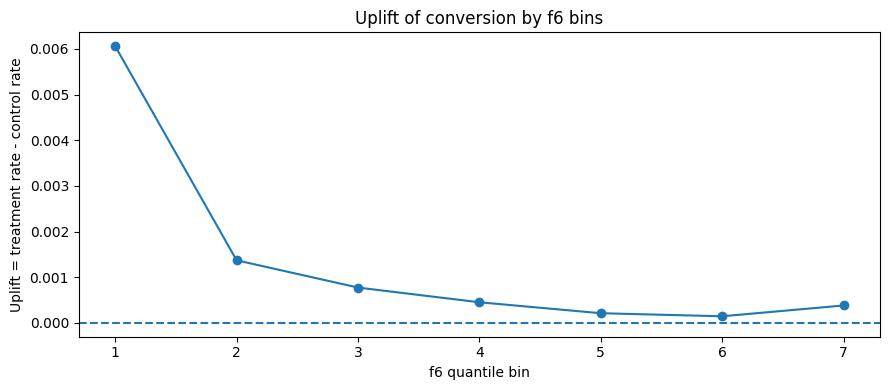

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,5.092919,0.003089,0.001938,11882655,2096937,36711,4063,0.001152,0.594488,0,"(4.832999999999999, 11.998]"


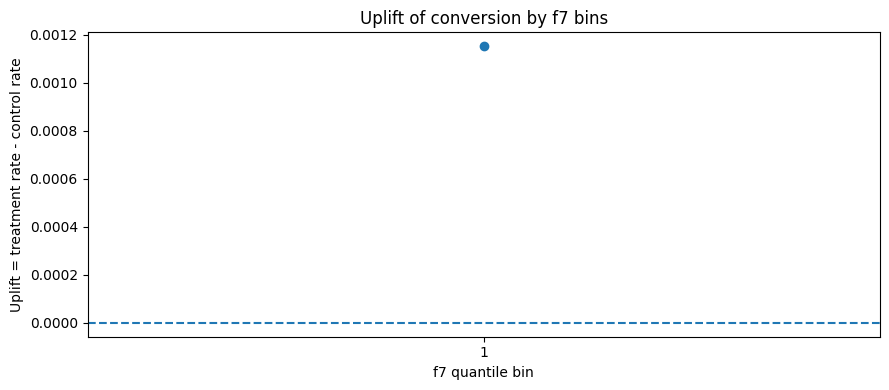

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,3.799819,0.024225,0.016330,1207773,198658,29258,3244,0.007895,0.483490,0,"(3.634, 3.843]"
1,3.870578,0.003804,0.002406,1228299,214076,4673,515,0.001399,0.581439,1,"(3.843, 3.893]"
2,3.913742,0.001130,0.000699,1277400,227365,1444,159,0.000431,0.616467,2,"(3.893, 3.927]"
3,3.940171,0.000415,0.000243,1156633,210064,480,51,0.000172,0.709335,3,"(3.927, 3.944]"
4,3.969944,0.000122,0.000075,7012550,1246774,856,94,0.000047,0.619040,4,"(3.944, 3.972]"


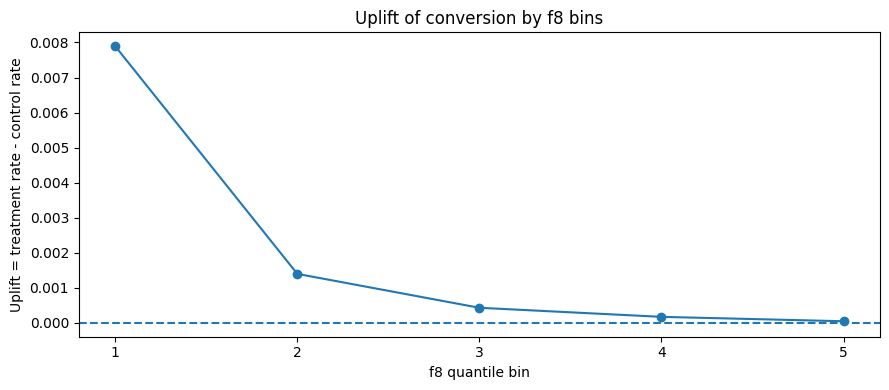

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,13.309404,0.000416,0.000248,9821021,1747126,4090,433,0.000169,0.680363,0,"(13.189, 16.226]"
1,20.953182,0.003550,0.002347,877120,154652,3114,363,0.001203,0.512546,1,"(16.226, 25.241]"
2,35.054367,0.024911,0.016740,1184514,195159,29507,3267,0.008170,0.488073,2,"(25.241, 75.295]"


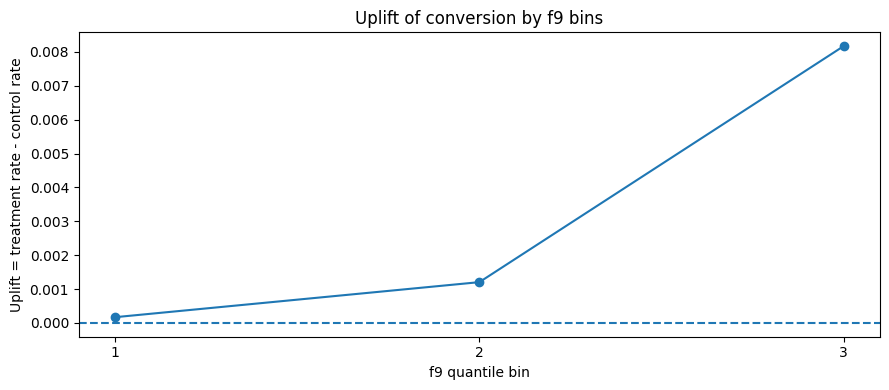

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,5.332779,0.003089,0.001938,11882655,2096937,36711,4063,0.001152,0.594488,0,"(5.2989999999999995, 6.474]"


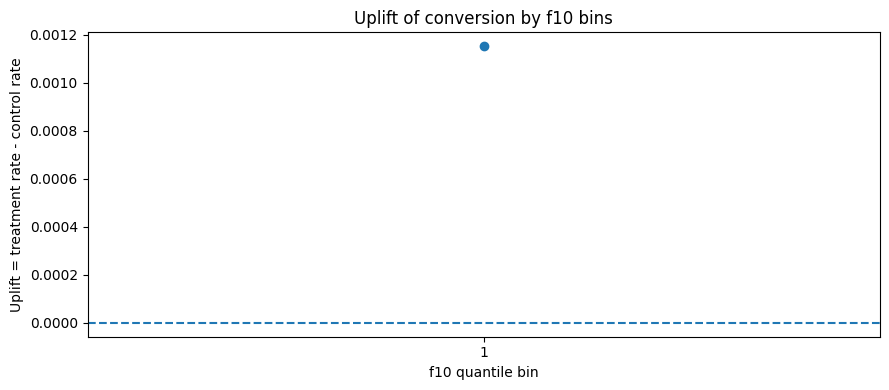

,feature_mean,rate_treatment,rate_control,n_treatment,n_control,positive_treatment,positive_control,uplift,relative_lift,bin_id,bin_label
0,-0.170926,0.003089,0.001938,11882655,2096937,36711,4063,0.001152,0.594488,0,"(-1.3849999999999998, -0.169]"


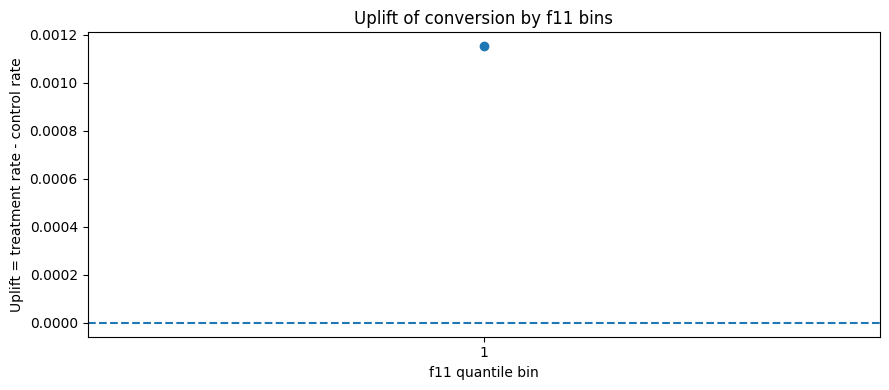

,feature,outcome,mean_abs_uplift_across_bins,max_uplift,min_uplift,uplift_range,min_n_treatment_bin,min_n_control_bin
9,f9,conversion,0.003181,0.008170,0.000169,0.008002,877120,154652
8,f8,conversion,0.001989,0.007895,0.000047,0.007849,1156633,198658
3,f3,conversion,0.003459,0.006521,0.000397,0.006124,1244949,193472
6,f6,conversion,0.001342,0.006061,0.000145,0.005916,1233216,195051
0,f0,conversion,0.000984,0.004105,0.000058,0.004047,1185084,199106
2,f2,conversion,0.001023,0.002536,0.000160,0.002376,1184594,206420
1,f1,conversion,0.001152,0.001152,0.001152,0.000000,11882655,2096937
4,f4,conversion,0.001152,0.001152,0.001152,0.000000,11882655,2096937
7,f7,conversion,0.001152,0.001152,0.001152,0.000000,11882655,2096937
5,f5,conversion,0.001152,0.001152,0.001152,0.000000,11882655,2096937


In [37]:
def binned_uplift(dataframe, feature, outcome, treatment_col="treatment", q=10):
    tmp = dataframe[[feature, outcome, treatment_col]].dropna().copy()
    tmp["bin"] = safe_quantile_bin(tmp[feature], q=q)

    grouped = tmp.groupby(["bin", treatment_col], observed=True).agg(
        n=(outcome, "size"),
        positive_count=(outcome, "sum"),
        outcome_rate=(outcome, "mean"),
        feature_mean=(feature, "mean")
    ).reset_index()

    # Pivot count và rate
    rate_pivot = grouped.pivot(index="bin", columns=treatment_col, values="outcome_rate")
    n_pivot = grouped.pivot(index="bin", columns=treatment_col, values="n")
    pos_pivot = grouped.pivot(index="bin", columns=treatment_col, values="positive_count")
    feature_mean = grouped.groupby("bin", observed=True)["feature_mean"].mean()

    result = pd.DataFrame(index=rate_pivot.index)
    result["feature_mean"] = feature_mean

    # Tên cột rõ ràng cho T=1 và T=0
    result["rate_treatment"] = rate_pivot[1] if 1 in rate_pivot.columns else np.nan
    result["rate_control"] = rate_pivot[0] if 0 in rate_pivot.columns else np.nan
    result["n_treatment"] = n_pivot[1] if 1 in n_pivot.columns else np.nan
    result["n_control"] = n_pivot[0] if 0 in n_pivot.columns else np.nan
    result["positive_treatment"] = pos_pivot[1] if 1 in pos_pivot.columns else np.nan
    result["positive_control"] = pos_pivot[0] if 0 in pos_pivot.columns else np.nan

    result["uplift"] = result["rate_treatment"] - result["rate_control"]
    result["relative_lift"] = result["rate_treatment"] / result["rate_control"] - 1
    result["bin_id"] = np.arange(len(result))
    result["bin_label"] = result.index.astype(str)

    return result.reset_index(drop=True)


def plot_binned_uplift(result, feature, outcome):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.axhline(0, linestyle="--")
    ax.plot(result["bin_id"], result["uplift"], marker="o")
    ax.set_title(f"Uplift of {outcome} by {feature} bins")
    ax.set_xlabel(f"{feature} quantile bin")
    ax.set_ylabel("Uplift = treatment rate - control rate")
    ax.set_xticks(result["bin_id"])
    ax.set_xticklabels(result["bin_id"] + 1)
    plt.tight_layout()
    plt.show()

if "treatment" in df.columns and PRIMARY_OUTCOME is not None:
    uplift_tables = {}
    uplift_feature_summary = []

    for feature in feature_cols:
        result = binned_uplift(df, feature, PRIMARY_OUTCOME, "treatment", q=10)
        uplift_tables[(feature, PRIMARY_OUTCOME)] = result

        uplift_feature_summary.append({
            "feature": feature,
            "outcome": PRIMARY_OUTCOME,
            "mean_abs_uplift_across_bins": result["uplift"].abs().mean(),
            "max_uplift": result["uplift"].max(),
            "min_uplift": result["uplift"].min(),
            "uplift_range": result["uplift"].max() - result["uplift"].min(),
            "min_n_treatment_bin": result["n_treatment"].min(),
            "min_n_control_bin": result["n_control"].min(),
        })

        display(result)
        plot_binned_uplift(result, feature, PRIMARY_OUTCOME)

    uplift_feature_summary = pd.DataFrame(uplift_feature_summary).sort_values("uplift_range", ascending=False)
    display(uplift_feature_summary)
else:
    print("Cần có treatment và outcome để tính uplift.")

## 16. Optional scatter plot: chỉ dùng sample và thêm jitter cho target binary

Nếu vẫn muốn giữ scatter plot như checklist ban đầu, nên dùng rất hạn chế:

- Chỉ vẽ trên sample nhỏ.
- Thêm jitter vào target binary để tránh mọi điểm chồng lên 2 đường ngang.
- Không dùng scatter plot làm bằng chứng chính; hãy ưu tiên binned rate/uplift ở các section trên.

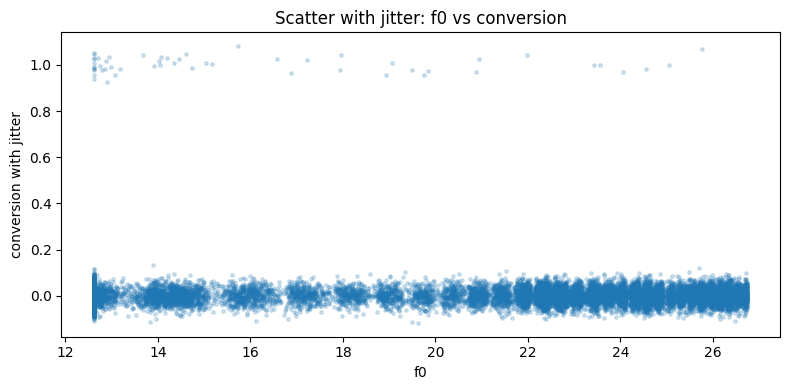

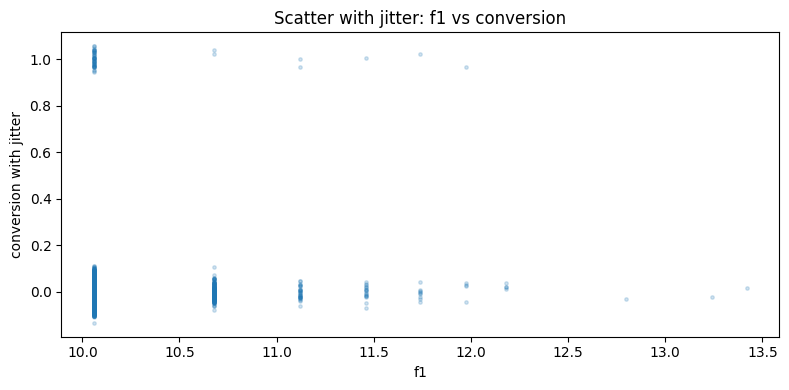

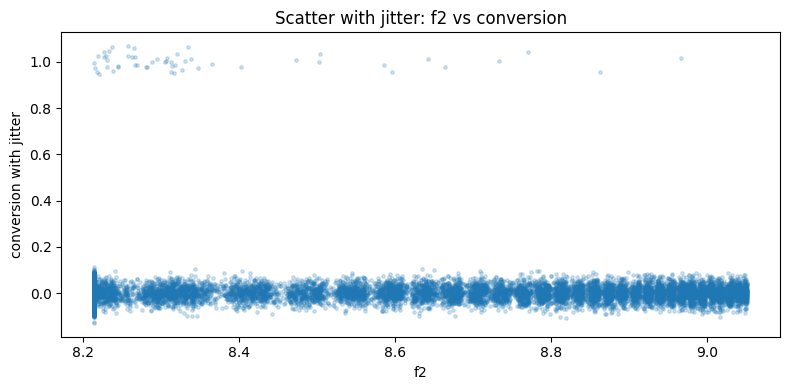

In [38]:
def plot_feature_target_scatter_with_jitter(dataframe, feature, outcome, sample_n=20_000, jitter=0.03):
    tmp = dataframe[[feature, outcome]].dropna()
    if len(tmp) > sample_n:
        tmp = tmp.sample(sample_n, random_state=RANDOM_STATE)

    y = tmp[outcome].astype(float).to_numpy()
    y_jitter = y + np.random.normal(0, jitter, size=len(y))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(tmp[feature], y_jitter, s=6, alpha=0.2)
    ax.set_title(f"Scatter with jitter: {feature} vs {outcome}")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"{outcome} with jitter")
    plt.tight_layout()
    plt.show()

if PRIMARY_OUTCOME is not None:
    # Chỉ demo một vài feature để tránh quá nhiều biểu đồ khó đọc.
    for feature in feature_cols[:3]:
        plot_feature_target_scatter_with_jitter(df, feature, PRIMARY_OUTCOME)
else:
    print("Không có outcome để vẽ scatter.")

## 17. Correlation và redundancy giữa các feature

Mục tiêu:
- Xem feature nào tương quan mạnh với nhau.
- Tìm feature gần duplicate hoặc dư thừa.

Vì các feature đã ẩn danh, ta không diễn giải business sâu, nhưng correlation vẫn giúp phát hiện redundancy cho modeling.

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
f0,1.000000,-0.086022,-0.514555,0.280570,-0.093442,0.053413,-0.270590,-0.000088,0.404888,-0.291799,-0.091798,0.078254
f1,-0.086022,1.000000,-0.012844,-0.329413,0.149221,-0.574309,-0.192257,0.151326,-0.143599,0.174166,0.069124,-0.150227
f2,-0.514555,-0.012844,1.000000,0.006778,0.024576,-0.022430,0.183739,0.035471,-0.372912,-0.051673,0.088895,0.030912
f3,0.280570,-0.329413,0.006778,1.000000,-0.199666,0.334220,0.549706,-0.204964,0.282054,-0.303108,-0.135873,0.171959
f4,-0.093442,0.149221,0.024576,-0.199666,1.000000,-0.197011,-0.159261,0.112939,-0.409904,0.364326,0.658277,-0.677701
f5,0.053413,-0.574309,-0.022430,0.334220,-0.197011,1.000000,0.362113,-0.746508,0.201885,-0.159930,-0.126846,0.122037
f6,-0.270590,-0.192257,0.183739,0.549706,-0.159261,0.362113,1.000000,-0.323578,0.118972,-0.106988,-0.123118,0.089329
f7,-0.000088,0.151326,0.035471,-0.204964,0.112939,-0.746508,-0.323578,1.000000,-0.143521,0.087290,0.095967,-0.050098
f8,0.404888,-0.143599,-0.372912,0.282054,-0.409904,0.201885,0.118972,-0.143521,1.000000,-0.750324,-0.401546,0.253150
f9,-0.291799,0.174166,-0.051673,-0.303108,0.364326,-0.159930,-0.106988,0.087290,-0.750324,1.000000,0.267429,-0.362990


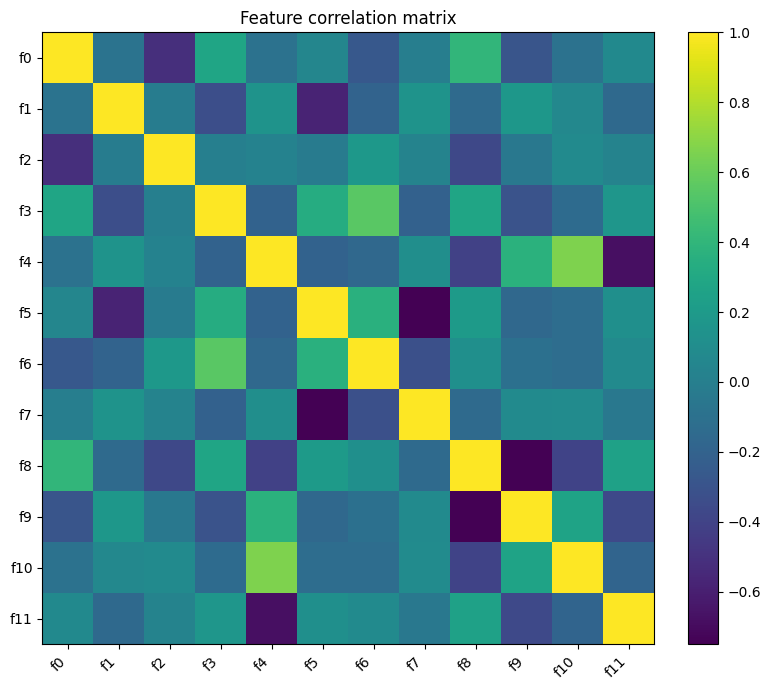

,feature_1,feature_2,abs_corr
60,f8,f9,0.750324
46,f5,f7,0.746508
44,f4,f11,0.677701
43,f4,f10,0.658277
14,f1,f5,0.574309
32,f3,f6,0.549706
1,f0,f2,0.514555
41,f4,f8,0.409904
7,f0,f8,0.404888
61,f8,f10,0.401546


In [39]:
if feature_cols:
    corr = df[feature_cols].corr()
    display(corr)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr)
    ax.set_xticks(range(len(feature_cols)))
    ax.set_yticks(range(len(feature_cols)))
    ax.set_xticklabels(feature_cols, rotation=45, ha="right")
    ax.set_yticklabels(feature_cols)
    ax.set_title("Feature correlation matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # Tìm cặp feature có absolute correlation cao
    corr_abs = corr.abs()
    mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
    high_corr_pairs = (
        corr_abs.where(mask)
        .stack()
        .reset_index()
    )
    high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
    high_corr_pairs = high_corr_pairs.sort_values("abs_corr", ascending=False)

    display(high_corr_pairs.head(30))
else:
    print("Không có feature columns.")

## 18. Phân tích riêng `exposure`

Nếu dataset có `exposure`, cần phân biệt rõ với `treatment`.

Các câu hỏi nên kiểm tra:
- `exposure=1` có chỉ xuất hiện trong nhóm `treatment=1` không?
- Outcome rate theo `exposure` khác thế nào?
- Nếu dùng `exposure` làm treatment trong model, có thể phát sinh bias vì exposure có thể phụ thuộc vào auction/winning và không còn ngẫu nhiên như treatment assignment.

Phần này chủ yếu để hiểu dữ liệu, chưa khuyến nghị dùng `exposure` làm treatment chính nếu mục tiêu là causal/uplift chuẩn.

In [40]:
if "exposure" in df.columns:
    print("Exposure value counts")
    display(df["exposure"].value_counts(dropna=False).to_frame("count"))

    print("Exposure rate:", df["exposure"].mean())

    if "treatment" in df.columns:
        print("Treatment x Exposure")
        display(pd.crosstab(df["treatment"], df["exposure"], margins=True))
        display(pd.crosstab(df["treatment"], df["exposure"], normalize="index"))

    if outcome_cols:
        exposure_outcomes = df.groupby("exposure")[outcome_cols].agg(["count", "sum", "mean"])
        display(exposure_outcomes)

        if "treatment" in df.columns:
            treatment_exposure_outcomes = df.groupby(["treatment", "exposure"])[outcome_cols].agg(["count", "sum", "mean"])
            display(treatment_exposure_outcomes)
else:
    print("Dataset không có cột exposure.")

Exposure value counts


,count
exposure,
0,13551380
1,428212


Exposure rate: 0.03063122299992732
Treatment x Exposure


exposure,0,1,All
treatment,,,
0,2096937,0,2096937
1,11454443,428212,11882655
All,13551380,428212,13979592


exposure,0,1
treatment,,
0,1.000000,0.000000
1,0.963963,0.036037


visit                  conversion                
             count     sum     mean      count    sum     mean
exposure                                                      
0         13551380  479419 0.035378   13551380  17743 0.001309
1           428212  177510 0.414538     428212  23031 0.053784

visit                  conversion                
                       count     sum     mean      count    sum     mean
treatment exposure                                                      
0         0          2096937   80105 0.038201    2096937   4063 0.001938
1         0         11454443  399314 0.034861   11454443  13680 0.001194
          1           428212  177510 0.414538     428212  23031 0.053784

## 19. Tổng hợp insight

In [41]:
eda_findings = []

eda_findings.append(f"Dataset shape đang phân tích: {df.shape[0]:,} rows x {df.shape[1]:,} columns.")
eda_findings.append(f"Số feature columns phát hiện: {len(feature_cols)}. Danh sách: {feature_cols}.")

if "treatment" in df.columns:
    treatment_rate = df["treatment"].mean()
    eda_findings.append(f"Treatment rate: {treatment_rate:.4%}; Control rate: {1 - treatment_rate:.4%}.")

if "exposure" in df.columns:
    exposure_rate = df["exposure"].mean()
    eda_findings.append(f"Exposure rate: {exposure_rate:.4%}.")

for outcome in outcome_cols:
    positive_rate = df[outcome].mean()
    positive_count = df[outcome].sum()
    eda_findings.append(f"Outcome {outcome}: positive_count={positive_count:,.0f}, positive_rate={positive_rate:.6%}.")

if "baseline_uplift" in globals() and len(baseline_uplift) > 0:
    for _, row in baseline_uplift.iterrows():
        eda_findings.append(
            f"Baseline uplift for {row['outcome']}: "
            f"{row['absolute_uplift']:.6%} absolute, {row['relative_lift']:.2%} relative."
        )

if "balance_table" in globals() and len(balance_table) > 0:
    top_imbalance = balance_table.iloc[0]
    eda_findings.append(
        f"Feature imbalance lớn nhất theo abs(SMD): {top_imbalance['feature']} "
        f"với abs(SMD)={top_imbalance['abs_smd']:.4f}."
    )

if "uplift_feature_summary" in globals() and len(uplift_feature_summary) > 0:
    top_uplift_feature = uplift_feature_summary.iloc[0]
    eda_findings.append(
        f"Feature có uplift_range lớn nhất theo quantile bins: {top_uplift_feature['feature']} "
        f"với uplift_range={top_uplift_feature['uplift_range']:.6%}."
    )

print("\n".join([f"- {x}" for x in eda_findings]))

- Dataset shape đang phân tích: 13,979,592 rows x 16 columns.
- Số feature columns phát hiện: 12. Danh sách: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11'].
- Treatment rate: 85.0000%; Control rate: 15.0000%.
- Exposure rate: 3.0631%.
- Outcome visit: positive_count=656,929, positive_rate=4.699200%.
- Outcome conversion: positive_count=40,774, positive_rate=0.291668%.
- Baseline uplift for visit: 1.034240% absolute, 27.07% relative.
- Baseline uplift for conversion: 0.115187% absolute, 59.45% relative.
- Feature imbalance lớn nhất theo abs(SMD): f3 với abs(SMD)=0.0488.
- Feature có uplift_range lớn nhất theo quantile bins: f9 với uplift_range=0.800182%.


## 20. Export các bảng EDA ra file CSV

Cell này lưu các bảng quan trọng để bạn dùng trong báo cáo hoặc README.

In [42]:
OUTPUT_DIR = Path("criteo_eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Lưu các bảng nếu đã tồn tại
objects_to_export = {
    "missing_summary": "missing_summary.csv",
    "inf_summary": "inf_summary.csv",
    "nunique_summary": "nunique_summary.csv",
    "feature_dictionary": "feature_dictionary.csv",
    "baseline_uplift": "baseline_uplift.csv",
    "balance_table": "treatment_control_balance.csv",
    "imbalance_table": "outcome_imbalance.csv",
    "uplift_feature_summary": "uplift_feature_summary.csv",
    "high_corr_pairs": "high_corr_pairs.csv",
}

for object_name, filename in objects_to_export.items():
    if object_name in globals():
        obj = globals()[object_name]
        if isinstance(obj, pd.DataFrame):
            obj.to_csv(OUTPUT_DIR / filename, index=True)
            print(f"Saved: {OUTPUT_DIR / filename}")

# Lưu từng bảng uplift theo feature nếu đã tồn tại
if "uplift_tables" in globals():
    uplift_dir = OUTPUT_DIR / "uplift_by_feature_bins"
    uplift_dir.mkdir(exist_ok=True)
    for (feature, outcome), table in uplift_tables.items():
        table.to_csv(uplift_dir / f"uplift_{outcome}_{feature}.csv", index=False)
    print(f"Saved uplift tables to: {uplift_dir}")

Saved: criteo_eda_outputs\missing_summary.csv
Saved: criteo_eda_outputs\inf_summary.csv
Saved: criteo_eda_outputs\nunique_summary.csv
Saved: criteo_eda_outputs\feature_dictionary.csv
Saved: criteo_eda_outputs\baseline_uplift.csv
Saved: criteo_eda_outputs\treatment_control_balance.csv
Saved: criteo_eda_outputs\outcome_imbalance.csv
Saved: criteo_eda_outputs\uplift_feature_summary.csv
Saved: criteo_eda_outputs\high_corr_pairs.csv
Saved uplift tables to: criteo_eda_outputs\uplift_by_feature_bins


## 21. Gợi ý kết luận cho notebook

Khi viết nhận xét cuối notebook, nên tập trung vào các điểm sau:

1. Dataset có feature ẩn danh nên không diễn giải business meaning của từng feature.
2. `conversion` thường là rare event, cần chú ý imbalance.
3. Cần phân biệt `treatment` và `exposure`.
4. Nếu treatment/control khá balanced theo SMD, dữ liệu phù hợp hơn cho uplift analysis.
5. Các feature có uplift thay đổi mạnh theo bin là ứng viên quan trọng cho heterogeneous treatment effect.
6. Raw scatter plot với target binary không hữu ích bằng binned rate/uplift.